In [1]:
import os 
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pysam
import pylab
import matplotlib.patches as patches
from scipy.stats import chi2_contingency
from collections import Counter

In [2]:
chroList = range(1,23)
chroList = [str(x) for x in chroList]
chroList +=['X'] + ['Y']

In [3]:
#read sample ID and sample name
sampleInfo = 'final_table/Sup_table_4_RNA_seq.xlsx'
sampleInfoDf = pd.read_excel(sampleInfo)


In [4]:
sampleInfoDf = sampleInfoDf.fillna('')

In [5]:
#cluster based on gene
geneDic = {}
gtfFileGenome = '/home/wenjingu/remillsscr/HPV_fusion/ref_hg19/Homo_sapiens.GRCh38.105.transcript.gtf'
with open(gtfFileGenome) as genome:
    rows = genome.read().rstrip().split('\n')
    for eachRow in rows:
        hasGeneName = False
        for each in eachRow.split('\t')[8].split(';'):
            if each.split('"')[0] == ' transcript_id ':
                trID = each.split('"')[1]
            if each.split('"')[0] == ' gene_name ':
                geneName = each.split('"')[1]
                hasGeneName = True
           
        chro = eachRow.split('\t')[0].replace('chr','')
        start = eachRow.split('\t')[3]
        end = eachRow.split('\t')[4]
        if hasGeneName:     
            if trID not in geneDic:
                geneDic[trID] = [geneName,chro,start,end]
            else:
                print(eachRow)
        else:
            if trID not in geneDic:
                geneDic[trID] = [trID,chro,start,end]

In [6]:
#question1: how many integrations in DNA but not in RNA and in RNA not in DNA

In [7]:
#sample with HPV ins, either DNA or RNA
n = 0
dnaSample = 0
rnaSample = 0
i = 0
for sample in sampleInfoDf['TCS ID']:
    sampleID = sampleInfoDf['TCS Sample name'][i]
    DNASite = sampleInfoDf['TCS Human Fusion'][i]
    RNASite = sampleInfoDf['RNA-seq Human Fusion'][i]
    if DNASite != '' or RNASite != '':
        n += 1
    if DNASite != '':
        dnaSample += 1
    if RNASite != '':
        rnaSample += 1
    i += 1

In [8]:
dnaSample

65

In [9]:
n

76

In [10]:
rnaSample

38

In [11]:
i = 0
notInRNAList = []
notInDNAList = []
commonListGene = []
commonListIntergenic = []
exactSamplePair = []
for each_sample in sampleInfoDf['TCS ID']:
    sample = str(each_sample)
    sampleID = str(sampleInfoDf['TCS Sample name'][i])
    DNASite = sampleInfoDf['TCS Human Fusion'][i]
    RNASite = sampleInfoDf['RNA-seq Human Fusion'][i]
    if pd.notna(sampleInfoDf['TCS Gene'][i]):
        DNAGene = sampleInfoDf['TCS Gene'][i].split(';')
    else:
        DNAGene = []
    if pd.notna(sampleInfoDf['RNA Gene'][i]):
        RNAGene = sampleInfoDf['RNA Gene'][i].split(';')
    else:
        RNAGene = []
    #compare the two
    
    if pd.notna(DNASite):
        j = 0
        for site1 in DNASite.split(';'):
            if site1 != '':
                chro1 = site1.split(':')[0]
                ins1 = site1.split(':')[1]
                notInRNA = True
                k = 0
                if pd.notna(RNASite):
                    for site2 in RNASite.split(';'):
                        if site2 != '':
                            chro2 = site2.split(':')[0]
                            ins2 = site2.split(':')[1]
                            if chro1 == chro2:
                                print(DNAGene[j],RNAGene[k])
                                if DNAGene[j] != 'intergenic' and RNAGene[k] != 'intergenic':
                                    for gene1 in DNAGene[j].split(','):
                                        for gene2 in RNAGene[k].split(','):
                                            if gene1 == gene2:
                                                notInRNA = False
                                                commonListGene.append([chro1,site1,site2,sample,sampleID,gene1])
                                                if int(ins1) == int(ins2):
                                                    exactSamplePair.append([chro1,site1,site2,sample,sampleID,gene1])
                                elif abs(int(ins1)-int(ins2)) < 50000:
                                    commonListIntergenic.append([chro1,site1,site2,sample,sampleID,'intergenic'])
                                    notInRNA = False
                                    if int(ins1) == int(ins2):
                                        exactSamplePair.append([chro1,site1,site2,sample,sampleID,'intergenic'])


                    k += 1
                if notInRNA:
                    notInRNAList.append([chro1,site1,site2,sample,sampleID])
            j += 1


                        
        
        
    #not in DNA
    if pd.notna(RNASite):
        j = 0
        for site2 in RNASite.split(';'):
            if site2 != '':
                chro2 = site2.split(':')[0]
                ins2 = site2.split(':')[1]
                notInDNA = True

               
                if pd.notna(DNASite):
                    k = 0
                    for site1 in DNASite.split(';'):
                        if site1 != '':
                            chro1 = site1.split(':')[0]
                            ins1 = site1.split(':')[1]
                            if chro1 == chro2:
                                if DNAGene[k] != 'intergenic' and RNAGene[j] != 'intergenic':
                                    for gene1 in DNAGene[k].split(','):
                                            for gene2 in RNAGene[j].split(','):
                                                if gene1 == gene2:
                                                    notInDNA = False
                                elif abs(int(ins1)-int(ins2)) < 50000:
                                    notInDNA = False

                        k += 1
                    if notInDNA:
                        notInDNAList.append([chro1,site1,site2,sample,sampleID])

            j += 1

        
    i += 1

XRCC1 RELB
ENST00000595955,CCDC61,ENST00000662557,ENST00000601033,PGLYRP1 RELB
PDE4D Y_RNA,LINC02899
PDE4D Y_RNA,LINC02899
PDE4D Y_RNA,LINC02899
PDE4D Y_RNA,LINC02899
PDE4D Y_RNA,LINC02899
PDE4D Y_RNA,LINC02899
LINC01170 Y_RNA,LINC02899
LINC01170 Y_RNA,LINC02899
LINC01170 Y_RNA,LINC02899
LINC01170 Y_RNA,LINC02899
LINC01170 Y_RNA,LINC02899
LINC01170 Y_RNA,LINC02899
intergenic Y_RNA,LINC02899
intergenic Y_RNA,LINC02899
intergenic Y_RNA,LINC02899
intergenic Y_RNA,LINC02899
intergenic Y_RNA,LINC02899
intergenic Y_RNA,LINC02899
ST8SIA4 LINC02899
ST8SIA4 LINC02899
ST8SIA4 LINC02899
ST8SIA4 LINC02899
intergenic LINC02899
intergenic LINC02899
intergenic LINC02899
intergenic LINC02899
LINC02056 LINC02899
LINC02056 LINC02899
LINC02056 LINC02899
LINC02056 LINC02899
ENST00000661858 PLGRKT,RNF152P1
ENST00000661858 PLGRKT,RNF152P1
BCORP1,TXLNGY PLGRKT,RNF152P1
BCORP1,TXLNGY PLGRKT,RNF152P1
ENST00000661858 PLGRKT,RNF152P1
ENST00000661858 PLGRKT,RNF152P1
ENST00000661858 PLGRKT,RNF152P1
ENST00000661858

In [12]:
len(set([",".join(x[0:-1]) for x in  exactSamplePair]))

20

In [13]:
uniqPair = []
sampleList = []
for site in commonListGene:
    uniqPair.append(site[0] + '.' + site[1] + '.' + site[2])
    sampleList.append(site[3])

In [14]:
commonListGene

[['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5441235', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:542

In [15]:
commonListDf = pd.DataFrame(commonListGene,columns = ['chro','DNAIns','RNAIns','Sample ID','TCS Sample ID','Gene'])


In [16]:
len(set(sampleList))

10

In [17]:
uniqPair = set(uniqPair)

In [18]:
uniqPair

{'10.10:88992756.10:88992531',
 '10.10:88992756.10:88992532',
 '10.10:88992756.10:88992648',
 '10.10:88992756.10:88992747',
 '12.12:1317260.12:1317260',
 '12.12:1317260.12:1317288',
 '12.12:1317260.12:1371828',
 '12.12:6352390.12:6352390',
 '12.12:6352390.12:6391184',
 '12.12:6352390.12:6516855',
 '12.12:6355692.12:6352390',
 '12.12:6355692.12:6391184',
 '12.12:6355692.12:6516855',
 '12.12:6360692.12:6352390',
 '12.12:6360692.12:6391184',
 '12.12:6360692.12:6516855',
 '12.12:6362161.12:6352390',
 '12.12:6362161.12:6391184',
 '12.12:6362161.12:6516855',
 '12.12:6368745.12:6352390',
 '12.12:6368745.12:6391184',
 '12.12:6368745.12:6516855',
 '12.12:6369056.12:6352390',
 '12.12:6369056.12:6391184',
 '12.12:6369056.12:6516855',
 '21.21:32568437.21:32568437',
 '21.21:32568437.21:32569194',
 '21.21:32568437.21:32570937',
 '21.21:32570937.21:32568437',
 '21.21:32570937.21:32569194',
 '21.21:32570937.21:32570937',
 '3.3:178023951.3:178029607',
 '3.3:178023951.3:178033809',
 '3.3:178023951.3:178

In [19]:
len(uniqPair)

149

In [20]:
uniqPair = []
sampleList = []
for site in commonListIntergenic:
    uniqPair.append(site[0] + '.' + site[1] + '.' + site[2])
    sampleList.append(site[3])

In [21]:
len(set(sampleList))

8

In [22]:
len(commonListIntergenic)

54

In [23]:
commonListIntergenicDf = pd.DataFrame(commonListIntergenic,columns = ['chro','DNAIns','RNAIns','Sample ID','TCS Sample ID','Gene'])

In [24]:
commonPairDf = pd.concat([commonListDf,commonListIntergenicDf]).drop_duplicates(keep = 'first',ignore_index = True)

In [25]:
len(set(uniqPair))

43

In [26]:
#write commonList to file
commonPairDf.to_csv('final_table/commonPairDNARNA.csv')

In [27]:
#read complex integration
complexInfo_1 = '../sup_1/TCSIntegrationList_dup_sup1.csv'
#complexInfo_2 = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.01.25.23/TCSIntegrationList_dup_CL.csv'
complexInfo_df1 = pd.read_csv(complexInfo_1)
#complexInfo_df2 = pd.read_csv(complexInfo_2)


In [28]:
#how many of DNA uniq is type1/type2
simpleList = []
complexList = []
for each in notInRNAList:
    isComplex = False
    commonIns = each[1].split(':')[1]
    chro = each[0]
    sampleID = each[4]
    i = 0
    print(commonIns,sampleID)
    for complexIns in complexInfo_df1['Ins']:
        if str(complexIns) == commonIns and chro == str(complexInfo_df1['Chro'][i]) \
        and 'Sample_' + sampleID == complexInfo_df1['SeqID'][i]:
            print(commonIns)
            complexList.append(','.join(each[0:2] + each[3:]))
            isComplex = True
        i += 1
    if not isComplex:
        simpleList.append(','.join(each[0:2] + each[3:]))

169630796 2789-CB-85
169630796
169630796
122202248 2789-CB-85
169496784 2789-CB-85
169496784
169496784
6354342 2789-CB-87
6354342
6354342
6339074 2789-CB-87
6339074
6339074
84336250 2789-CB-87
88473737 2789-CB-87
56010465 2789-CB-87
43675741 2789-CB-87
6354086 2789-CB-87
6354086
6354086
6354086 2789-CB-87
6354086
6354086
6353831 2789-CB-87
6353831
6353831
6353831 2789-CB-87
6353831
6353831
194352494 2789-CB-87
73626178 2789-CB-87
6339182 2789-CB-87
6339182
6339182
95254483 2789-CB-87
13434476 2789-CB-87
16891401 2789-CB-87
6341536 2789-CB-87
6341536
6341536
6348050 2789-CB-87
6348050
6348050
76955413 2789-CB-87
6351634 2789-CB-87
6351634
6351634
6392812 2789-CB-87
6392812
6392812
49698673 2789-CB-87
37620717 2789-CB-87
6353271 2789-CB-87
6353271
6353271
6353271 2789-CB-87
6353271
6353271
42883966 2789-CB-87
53309586 2789-CB-87
43544513 2789-CB-87
46026128 2789-CB-87
60342711 2789-CB-87
105196210 2789-CB-87
29163079 2789-CB-87
6382148 2789-CB-87
6382148
6382148
6382148 2789-CB-87
638214

137795407 2655-CB-22
64228184 2655-CB-22
135702516 2655-CB-22
51225533 2655-CB-22
104028104 2655-CB-22
31330310 2655-CB-22
43770620 2655-CB-22
43770620
43770620 2655-CB-22
43770620
181220062 2655-CB-22
43770467 2655-CB-22
43770467
43770467 2655-CB-22
43770467
41312646 2655-CB-22
18297283 2655-CB-22
12707457 2655-CB-22
196695063 2655-CB-22
18715045 2655-CB-22
109195867 2655-CB-22
31318671 2655-CB-22
128515666 2655-CB-22
64084752 2655-CB-22
1419941 2655-CB-22
96166425 2655-CB-22
76616201 2655-CB-22
58361555 2655-CB-26
112768053 2655-CB-26
20106500 2655-CB-26
47245495 2655-CB-26
234898564 2655-CB-26
142258499 2655-CB-26
113996399 2655-CB-26
139159117 2655-CB-26
234897852 2655-CB-26
30589018 2655-CB-26
32339036 2655-CB-26
65995564 2655-CB-26
119822381 2655-CB-26
234898564 2655-CB-27
4133069 2655-CB-27
234897901 2655-CB-27
30309220 2655-CB-27
79202716 2655-CB-27
51022452 2655-CB-27
14600865 2655-CB-27
115467489 2655-CB-27
5518732 2655-CB-27
60549793 2655-CB-27
234897624 2655-CB-27
128940044

In [29]:
len(set(simpleList))

1553

In [30]:
len(set(complexList))

103

In [31]:
notInRNAList

[['3', '3:169630796', '2:38486630', 'SOP-074-B', '2789-CB-85'],
 ['5', '5:122202248', '2:38486630', 'SOP-074-B', '2789-CB-85'],
 ['3', '3:169496784', '2:38486630', 'SOP-074-B', '2789-CB-85'],
 ['12', '12:6354342', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6339074', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['6', '6:84336250', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['14', '14:88473737', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['11', '11:56010465', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['20', '20:43675741', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6354086', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6354086', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6353831', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6353831', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['3', '3:194352494', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['13', '13:73626178', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6339182', '19

In [32]:
len(set(sampleList))

8

In [33]:
notInRNAList

[['3', '3:169630796', '2:38486630', 'SOP-074-B', '2789-CB-85'],
 ['5', '5:122202248', '2:38486630', 'SOP-074-B', '2789-CB-85'],
 ['3', '3:169496784', '2:38486630', 'SOP-074-B', '2789-CB-85'],
 ['12', '12:6354342', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6339074', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['6', '6:84336250', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['14', '14:88473737', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['11', '11:56010465', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['20', '20:43675741', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6354086', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6354086', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6353831', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6353831', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['3', '3:194352494', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['13', '13:73626178', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '12:6339182', '19

In [34]:
simpleList = []
complexList = []
for each in notInDNAList:
    isComplex = False
    commonIns = each[2].split(':')[1]
    chro = each[0]
    sampleID = each[4]
    i = 0
    print(commonIns,sampleID)
    for complexIns in complexInfo_df1['Ins']:
        if str(complexIns) == commonIns and chro == str(complexInfo_df1['Chro'][i]) \
        and 'Sample_' + sampleID == complexInfo_df1['SeqID'][i]:
            print(commonIns)
            complexList.append(','.join(each[0:2] + each[3:]))
            isComplex = True
        i += 1
    if not isComplex:
        simpleList.append(','.join(each[0:2] + each[3:]))

38486630 2789-CB-85
45007892 2789-CB-87
11249762 2789-CB-94
13730514 2789-CB-94
13730863 2789-CB-94
11254951 2789-CB-94
13738650 2789-CB-94
123342472 109332
123328690 109332
123319515 109332
123319502 109332
23993885 2920-CB-19
23988527 2920-CB-19
23988715 2920-CB-19
23988526 2920-CB-19
23993891 2920-CB-19
23988714 2920-CB-19
23988526 2920-CB-20
23993891 2920-CB-20
23993885 2920-CB-20
23988714 2920-CB-20
138279657 83060
4980139 
4981389 
4980910 
43741665 2655-CB-22
43549740 2655-CB-22
43743722 2655-CB-22
44193621 2655-CB-41
44192166 2655-CB-41
79091097 
68456340 
98574802 
139851455 
139910288 
139862065 
139894375 
139923570 
139908265 
146808481 
146815029 
146815030 
146830235 
102815778 
146844095 
146822675 
146793604 
156763518 
43874931 152-CB-36
38327568 
38327568 
38357117 
38357696 
108537990 
108488531 
108492995 
108491325 
69044192 
69044205 
108494427 
108493305 
108497466 
108552347 
69072391 
70234020 
70232331 
70232992 
181888509 2920-CB-94
181888480 2920-CB-94
18195

In [35]:
len(set([x[2] + '.' + x[4] for x in notInDNAList]))

82

In [36]:
notInDNAList

[['3', '3:169496784', '2:38486630', 'SOP-074-B', '2789-CB-85'],
 ['12', '12:45930442', '19:45007892', 'SOP-075-A', '2789-CB-87'],
 ['12', '', '16:11249762', 'SOP-077-A', '2789-CB-94'],
 ['12', '', '9:13730514', 'SOP-077-A', '2789-CB-94'],
 ['12', '', '9:13730863', 'SOP-077-A', '2789-CB-94'],
 ['12', '', '16:11254951', 'SOP-077-A', '2789-CB-94'],
 ['12', '', '9:13738650', 'SOP-077-A', '2789-CB-94'],
 ['X', 'X:31964714', '9:123342472', '4399T', '109332'],
 ['X', 'X:31964714', '9:123328690', '4399T', '109332'],
 ['X', 'X:31964714', '9:123319515', '4399T', '109332'],
 ['X', 'X:31964714', '9:123319502', '4399T', '109332'],
 ['9', '9:13031277', '5:23993885', 'SOP-015-B', '2920-CB-19'],
 ['9', '9:13031277', '5:23988527', 'SOP-015-B', '2920-CB-19'],
 ['9', '9:13031277', '5:23988715', 'SOP-015-B', '2920-CB-19'],
 ['9', '9:13031277', '5:23988526', 'SOP-015-B', '2920-CB-19'],
 ['9', '9:13031277', '5:23993891', 'SOP-015-B', '2920-CB-19'],
 ['9', '9:13031277', '5:23988714', 'SOP-015-B', '2920-CB-19

In [37]:
len(set(sampleList))

8

In [38]:
commonListGene

[['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5441235', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:542

In [39]:
##question2: #of RNA fusion/# of DNA fusion complex vs simple
simpleList = []
complexList = []
for each in commonListGene:
    isComplex = False
    commonIns = each[1].split(':')[1]
    chro = each[0]
    sampleID = each[4]
    i = 0
    print(commonIns,sampleID)
    for complexIns in complexInfo_df1['Ins']:
        if str(complexIns) == commonIns and chro == str(complexInfo_df1['Chro'][i]) \
        and 'Sample_' + sampleID == complexInfo_df1['SeqID'][i]:
            print(commonIns)
            complexList.append(','.join(each[0:2] + each[3:-1]))
            isComplex = True
        i += 1
    if not isComplex:
        simpleList.append(','.join(each[0:2] + each[3:-1]))

5422685 83062
5422685
5422685 83062
5422685
5422685 83062
5422685
5422685 83062
5422685
5422685 83062
5422685
5422685 83062
5422685
5422685 83062
5422685
5422685 83062
5422685
5441235 83062
5441235
5441235 83062
5441235
5441235 83062
5441235
5441235 83062
5441235
5441465 83062
5441465
5441465 83062
5441465
5441465 83062
5441465
5441465 83062
5441465
5423555 83062
5423555
5423555 83062
5423555
5423555 83062
5423555
5423555 83062
5423555
5393316 83062
5393316
5393316 83062
5393316
5365469 83062
5365469
5365469 83062
5365469
5425057 83062
5425057
5425057 83062
5425057
5379722 83062
5379722
5379722 83062
5379722
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068
27713068 83081
27713068


In [40]:
len(set(complexList))

37

In [41]:
len(set(simpleList))

8

In [42]:
commonListGene

[['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5441235', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:542

In [43]:
for each in commonListGene:
    commonIns = each[1].split(':')[1]
    chro = each[0]
    sampleID = each[3]
    i = 0
    print(commonIns,sampleID)
    for complexIns in complexInfo_df1['Ins']:
        if str(complexIns) == commonIns and chro == str(complexInfo_df1['Chro'][i]) \
        and 'Sample_' + sampleID == complexInfo_df1['SeqID'][i]:
            print(commonIns)
        i += 1
            

5422685 HNSpore4068T
5422685 HNSpore4068T
5422685 HNSpore4068T
5422685 HNSpore4068T
5422685 HNSpore4068T
5422685 HNSpore4068T
5422685 HNSpore4068T
5422685 HNSpore4068T
5441235 HNSpore4068T
5441235 HNSpore4068T
5441235 HNSpore4068T
5441235 HNSpore4068T
5441465 HNSpore4068T
5441465 HNSpore4068T
5441465 HNSpore4068T
5441465 HNSpore4068T
5423555 HNSpore4068T
5423555 HNSpore4068T
5423555 HNSpore4068T
5423555 HNSpore4068T
5393316 HNSpore4068T
5393316 HNSpore4068T
5365469 HNSpore4068T
5365469 HNSpore4068T
5425057 HNSpore4068T
5425057 HNSpore4068T
5379722 HNSpore4068T
5379722 HNSpore4068T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore4005T
27713068 HNSpore

In [44]:
commonListGene

[['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5423555', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5422685', '9:5422685', 'HNSpore4068T', '83062', 'RNF152P1'],
 ['9', '9:5441235', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441235', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:5423555', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:5422685', 'HNSpore4068T', '83062', 'PLGRKT'],
 ['9', '9:5441465', '9:542

In [45]:
complexInsDic = {}
i = 0
allComplex = []
commonComplex = []
for complexIns in complexInfo_df1['Ins']:
    allComplex.append(str(complexInfo_df1['Chro'][i]) + ':' + str(complexIns))
    for each in commonListGene:
        commonIns = each[1].split(':')[1]
        chro = each[0]
        sampleID = each[4]
        gene = each[5]
        print(sampleID)
        if str(complexIns) == commonIns and chro == str(complexInfo_df1['Chro'][i]) \
        and 'Sample_' + sampleID == complexInfo_df1['SeqID'][i]:
            commonComplex.append(','.join(each))
            key = gene + '.' + sampleID
            if key in complexInsDic:
                complexInsDic[key].append(each)
            else:
                complexInsDic[key] = [each]
    
            
            
            
            
            
    i += 1
    

83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26

126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
2655-CB-57
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152

83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-26
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB-27
2655-CB

6670-CB-15
6670-CB-15
6670-CB-15
6670-CB-15
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
126473
2655-CB-26
2655-CB-26
2655-CB-26

152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-30
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
152-CB-14
6670-CB-19
6670-CB-19
6670-CB-19
6670-CB-19
6670-CB-19
6670-CB-19
6670-CB-20
6670-CB-20
6670-CB-20
6670-CB-20
6670-CB-20
6670-CB-20
6670-CB-20
6670-CB-20
6670-CB-20
6670-CB-15
6670-CB-15
6670-CB-15
6670-CB-15
6670-CB-15
6670-CB-15
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83062
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
83081
8

In [46]:
 commonComplex = set(commonComplex)

In [47]:
uniqPair = []
for each in commonComplex:
    uniqPair.append(','.join(each.split(',')[0:3]))

In [48]:
uniqPair = set(uniqPair)

In [49]:
len(uniqPair)

134

In [50]:
complexInfo_df1

,SampleID,SeqID,Chro,Ins,SPCov,hpvIns,Conf,numIns,GeneFallInto,GeneWithin50k
0,2655-CB-78,Sample_2655-CB-78,11,59110346,0.306153,3077;,low;,9,FAM111B,ENST00000529891;ENST00000688864;GLYATL1B;FAM11...
1,2655-CB-78,Sample_2655-CB-78,11,59167526,0.229615,1538;,low;,9,NaN,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
2,2655-CB-78,Sample_2655-CB-78,11,59172823,0.382692,6022;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
3,2655-CB-78,Sample_2655-CB-78,11,59173849,0.306153,2540;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
4,2655-CB-78,Sample_2655-CB-78,11,59174615,0.153077,6719;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
...,...,...,...,...,...,...,...,...,...,...
547,SOP-021,Sample_2920-CB-83,9,123319363,0.499898,1767;,high;,7,NaN,CRB2
548,SOP-021,Sample_2920-CB-83,9,123319477,0.514959,1767;,high;,7,NaN,CRB2
549,SOP-021,Sample_2920-CB-83,9,123357240,0.999796,5585;,low;,7,CRB2,DENND1A;MIR601;CRB2
550,SOP-074,Sample_2789-CB-85,3,169496784,0.705088,1894;,high;,2,MECOM,MECOM;MECOM-AS1;RPL22P1


In [51]:
sampleInfoDf

,Unnamed: 0,RNA Sample ID,TCS Resp ID,TCS ID,TCS Sample name,Core ng/ul,ul Remaining,Total ng,RIN,DV200,...,iDC,ly Endothelial cells,mv Endothelial cells,naive B-cells,pDC,pro B-cells,ImmuneScore,StromaScore,MicroenvironmentScore,HPV integration type (based on TCS Human Fusion)
0,0,3266-CB-1,3832,HNSpore3832T,83040,474.0,37.0,17538.0,1.4,27.00,...,0.1469,0.0948,0.1407,0.0573,0.0122,0.0041,0.7870,0.1531,0.9400,
1,1,3266-CB-10,4000,HNSpore4000T,83038,61.0,38.0,2318.0,2.3,27.00,...,0.2984,0.1443,0.0969,0.1675,0.2265,0.0566,1.3727,0.2396,1.6124,
2,2,3266-CB-102,SOP-074-B,SOP-074-B,2789-CB-85,71.2,38.0,2706.0,1.7,51.00,...,0.0000,0.0784,0.0376,0.0438,0.0884,0.0882,0.4945,0.1386,0.6332,Type2
3,3,3266-CB-103,SOP-075-A,SOP-075-A,2789-CB-87,107.0,37.0,3959.0,1.0,45.00,...,0.0000,0.0378,0.0687,0.0790,0.1397,0.0126,0.4687,0.1852,0.6539,Type2
4,4,3266-CB-104,SOP-075-B,SOP-075-B,2789-CB-88,67.2,37.0,2486.0,1.8,61.00,...,0.1080,0.0783,0.1396,0.0000,0.1528,0.0388,0.4299,0.1144,0.5442,Type2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,149,5343-CB-2,3173,3173,6670-CB-87,162.0,18.0,2916.0,7.4,93.21,...,0.1209,0.0406,0.0628,0.0867,0.1604,0.0823,0.8028,0.0778,0.8806,Type1
150,150,5343-CB-3,3749,3749,6670-CB-93,170.0,16.0,2720.0,6.7,92.24,...,0.1098,0.0972,0.1168,0.0481,0.0234,0.0298,0.7221,0.1271,0.8493,Type0
151,151,5343-CB-4,2352,2352,6670-CB-88,184.5,18.0,3321.0,4.9,86.42,...,0.0556,0.0498,0.0599,0.0730,0.0386,0.0980,0.3357,0.0548,0.3904,Type0
152,152,5343-CB-5,,,,166.5,18.0,2997.0,5.0,88.70,...,0.0000,0.0275,0.0000,0.0164,0.0000,0.1162,0.1401,0.0088,0.1489,


In [52]:
clusteredSite = {}
clusteredDNAComplexRes = {}

for sample in set(complexInfo_df1['SampleID']):
    #cluster site within 500kb
    clusteredSite[sample] = {}
    clusteredDNAComplexRes[sample] = {}
i = 0
for sample in complexInfo_df1['SampleID']:
    chro1 = complexInfo_df1['Chro'][i]
    ins1 = complexInfo_df1['Ins'][i]
    if chro1 in clusteredSite[sample]:
        clusteredSite[sample][chro1].append(ins1)
    else:
        clusteredSite[sample][chro1] = [ins1]
    i += 1
for sample in clusteredSite:
    for eachChro in clusteredSite[sample]:
        print(clusteredSite[sample][eachChro])
        a = np.array(clusteredSite[sample][eachChro])
        #print(a)
        a = sorted(clusteredSite[sample][eachChro])
        deltaList = [0]
        for i in range(len(a)-1):
            deltaList.append(abs(a[i+1]-a[i]))
        cutList = []
        for i in range(len(deltaList)):
            if deltaList[i] > 500000:
                cutList.append(i)
        #print(cutList)
        if cutList != []:
            clusteredDNAComplexRes[sample][eachChro] = [a[0:cutList[0]],a[cutList[-1]:]]#add the first and last slots
            for i in range(len(cutList)-1):
                clusteredDNAComplexRes[sample][eachChro].append(a[cutList[i]:cutList[i+1]])
        else:
            clusteredDNAComplexRes[sample][eachChro] = [a]
clusteredDNAComplexResNew = {}
for sample in clusteredDNAComplexRes:
    clusteredDNAComplexResNew[sample] = {}
    for chro in clusteredDNAComplexRes[sample]:
        for cluster in clusteredDNAComplexRes[sample][chro]:
            if chro in clusteredDNAComplexResNew[sample]:
                clusteredDNAComplexResNew[sample][chro].append(list(set(cluster)))
            else:
                clusteredDNAComplexResNew[sample][chro] = [list(set(cluster))]



[27705191, 27713068, 27716533, 27721327, 27722807, 27733597]
[10538746, 10539457, 10540335, 10541611]
[119035396, 119042561]
[59110346, 59167526, 59172823, 59173849, 59174615, 59181727, 59188274, 59188414, 59189272]
[72388388, 72393269, 72399939]
[152138366, 152170808, 152171427, 152182433]
[68332375, 68333889]
[24821024, 24821204]
[182327899, 182348334, 182384355, 182386452, 182390691, 177981230, 177992275, 178023951, 178032895, 178033606, 178033809, 178053238, 178053394, 178053746, 178067939, 178068058, 178071520]
[90977852, 90979913, 91067077, 91067446]
[42030689, 42043278, 42045415, 42059834]
[138415172, 138415548, 138417741, 138428965]
[73623878, 73801521]
[38419564, 38486513, 38486674]
[16582824, 16583087, 16590709, 16591874, 16596613, 16599150, 16635686, 16694960]
[105161799, 105165886]
[68914808, 69282802]
[21293580, 21375677]
[181776637, 181852649, 181860233, 181861449]
[73541345, 73753414, 73840383, 73840496, 73876999]
[89012402, 89027765, 89068656]
[138927249, 138956285, 138

In [53]:
clusteredDNAComplexResNew

{'83081': {'3': [[27705191,
    27713068,
    27721327,
    27716533,
    27722807,
    27733597]]},
 '2655-CB-51': {'4': [[10539457, 10538746, 10541611, 10540335]]},
 'MIOTO-4497': {'4': [[119042561, 119035396]]},
 '2655-CB-78': {'11': [[59167526,
    59110346,
    59172823,
    59188274,
    59174615,
    59189272,
    59173849,
    59188414,
    59181727]]},
 '109371': {'X': [[72399939, 72388388, 72393269]],
  '7': [[152170808, 152182433, 152171427, 152138366]]},
 '6670-CB-36': {'14': [[68333889, 68332375]]},
 '2920-CB-6': {'20': [[24821024, 24821204]]},
 '126473': {'3': [[178071520,
    178067939,
    178033606,
    177981230,
    178023951,
    178033809,
    178053394,
    177992275,
    178053746,
    178053238,
    178068058,
    178032895],
   [182390691, 182384355, 182348334, 182386452, 182327899]],
  '7': [[90979913, 90977852, 91067077, 91067446]]},
 '115306': {'1': [[42030689, 42059834, 42043278, 42045415]]},
 '2655-CB-97': {'8': [[138415548, 138428965, 138415172, 138417741

In [54]:
clusteredSite = {}
clusteredDNAComplexRes = {}

i = 0
count = 0
sampleID = []
patientID = []

j = 0
for ins2 in sampleInfoDf['TCS Human Fusion']:
    if pd.notna(ins2):
        for ins in ins2.split(';'):
            #print(str(complexInfo_df1['Chro'][i]) + ':' + str(complexIns),sampleInfoDf['Sample name'][j])
            for sample1 in clusteredDNAComplexResNew:
                for chro in clusteredDNAComplexResNew[sample1]:
                    for cluster in clusteredDNAComplexResNew[sample1][chro]:
                        isCommon = False
                        for ins1 in cluster:
                            if ins == str(chro) + ':' + str(ins1) and \
                            sample1 in 'Sample_' + str(sampleInfoDf['TCS Sample name'][j]):


                                sampleID.append(sampleInfoDf['TCS Sample name'][j])
                                patientID.append(sample1)
                                isCommon = True
                        if isCommon:
                            count += 1
                            print(cluster)


    j += 1

[169496784, 169630796]
[169496784, 169630796]
[6341536, 6339074, 6353955, 6382148, 6354086, 6353575, 6353831, 6354342, 6354730, 6372043, 6392812, 6339182, 6401039, 6348050, 6351634, 6353271]
[6341536, 6339074, 6353955, 6382148, 6354086, 6353575, 6353831, 6354342, 6354730, 6372043, 6392812, 6339182, 6401039, 6348050, 6351634, 6353271]
[6341536, 6339074, 6353955, 6382148, 6354086, 6353575, 6353831, 6354342, 6354730, 6372043, 6392812, 6339182, 6401039, 6348050, 6351634, 6353271]
[6341536, 6339074, 6353955, 6382148, 6354086, 6353575, 6353831, 6354342, 6354730, 6372043, 6392812, 6339182, 6401039, 6348050, 6351634, 6353271]
[6341536, 6339074, 6353955, 6382148, 6354086, 6353575, 6353831, 6354342, 6354730, 6372043, 6392812, 6339182, 6401039, 6348050, 6351634, 6353271]
[6341536, 6339074, 6353955, 6382148, 6354086, 6353575, 6353831, 6354342, 6354730, 6372043, 6392812, 6339182, 6401039, 6348050, 6351634, 6353271]
[6341536, 6339074, 6353955, 6382148, 6354086, 6353575, 6353831, 6354342, 6354730, 63

[182390691, 182384355, 182348334, 182386452, 182327899]
[178071520, 178067939, 178033606, 177981230, 178023951, 178033809, 178053394, 177992275, 178053746, 178053238, 178068058, 178032895]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59181727]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59181727]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59181727]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59181727]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59181727]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59181727]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59181727]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59181727]
[59167526, 59110346, 59172823, 59188274, 59174615, 59189272, 59173849, 59188414, 59

In [55]:
count

143

In [56]:
allInsList = []
for ins2 in sampleInfoDf['TCS Human Fusion']:
    for ins in ins2.split(';'):
        if ins != '':
            allInsList.append(ins)

In [57]:
len(allInsList)

1779

In [58]:
len(set(sampleInfoDf['TCS Sample name']))

107

In [59]:
count

143

In [60]:
len(set(sampleID))

16

In [61]:
len(set(patientID))

16

In [62]:
len(set(complexInfo_df1['SeqID']))

73

In [63]:
len(set(complexInfo_df1['SampleID']))

66

In [64]:
len(allComplex)

552

In [65]:
len(complexInfo_df1)

552

In [66]:
count = 0
sampleID = []
countRNA = 0
for key in complexInsDic:
    insList = []
    insRNAList = []
    for each in complexInsDic[key]:
        insList.append(each[1])
        insRNAList.append(each[2])
    print(insList,insRNAList)
    count += len(set(insList))
    countRNA += len(set(insRNAList))
    sampleID.append(key.split('.')[1])

['3:178023951', '3:178023951', '3:178023951', '3:178032895', '3:178032895', '3:178032895', '3:178033606', '3:178033606', '3:178033606', '3:178033809', '3:178033809', '3:178033809', '3:178053238', '3:178053238', '3:178053238', '3:178053394', '3:178053394', '3:178053394', '3:178053746', '3:178053746', '3:178053746', '3:178067939', '3:178067939', '3:178067939', '3:178068058', '3:178068058', '3:178068058', '3:178071520', '3:178071520', '3:178071520'] ['3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607', '3:178033809', '3:178053238', '3:178029607']
['3:48087390', '3:48087390', '3:48087920', '3:48087920', '3:48087920', '3:48087920'] ['3:48087910'

In [67]:
countRNA

40

In [68]:
count

41

In [69]:
sampleID

['126473',
 '6670-CB-19',
 '83062',
 '83062',
 '83081',
 '83081',
 '152-CB-14',
 '2655-CB-57']

In [70]:
len(set(sampleID))

6

In [71]:
complexInsDic

{'ENST00000651726.126473': [['3',
   '3:178023951',
   '3:178033809',
   '4494T',
   '126473',
   'ENST00000651726'],
  ['3', '3:178023951', '3:178053238', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178023951', '3:178029607', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178032895', '3:178033809', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178032895', '3:178053238', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178032895', '3:178029607', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178033606', '3:178033809', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178033606', '3:178053238', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178033606', '3:178029607', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178033809', '3:178033809', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178033809', '3:178053238', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178033809', '3:178029607', '4494T', '126473', 'ENST00000651726'],
  ['3', '3:178053238', '3:178033809

In [72]:
count

41

In [73]:
len(complexInsDic)

8

In [74]:
len(commonListGene)

260

In [75]:
commonHum = []
for each in commonListGene:
    commonHum.append(each[2])

In [76]:
len(set(commonHum))

36

In [77]:
i = 0
for each in commonListIntergenic:
    if each[1] in allComplex:
        print(each[1])
        i += 1

3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:27733597
3:177992275
3:177992275
3:177981230
6:52926514
6:52926514
6:52926514
6:52926514
6:52926514
6:52926514
6:52926514
6:52926514
4:73801521
4:73801521
4:73801521


In [78]:
ratioList = []
numList = []
allDNA = []
for ins in complexInsDic:
    DNAList = []
    RNAList = []
    for pair in complexInsDic[ins]:
        DNAList.append(pair[1])
        allDNA.append(pair[1] + '.' + ins.split('.')[1])
        RNAList.append(pair[2])
    print(set(RNAList))
    print(set(DNAList))
    ratioList.append(len(set(RNAList))/len(set(DNAList)))
    numList.append([len(set(RNAList)),len(set(DNAList))])

{'3:178029607', '3:178033809', '3:178053238'}
{'3:178033809', '3:178053394', '3:178053746', '3:178068058', '3:178023951', '3:178053238', '3:178071520', '3:178033606', '3:178032895', '3:178067939'}
{'3:48087920', '3:48087910'}
{'3:48087390', '3:48087920'}
{'9:5423555', '9:5422685'}
{'9:5423555', '9:5393316', '9:5422685', '9:5365469', '9:5379722', '9:5441235', '9:5425057', '9:5441465'}
{'9:5423555', '9:5422685'}
{'9:5423555', '9:5422685'}
{'3:27712429', '3:27713068', '3:27712158', '3:27712322', '3:27712807', '3:27711686', '3:27716533', '3:27721327', '3:27713413', '3:27713411', '3:27711685', '3:27712159', '3:27705191'}
{'3:27713068', '3:27716533'}
{'3:27712429', '3:27713068', '3:27712158', '3:27712322', '3:27712807', '3:27711686', '3:27716533', '3:27721327', '3:27713413', '3:27713411', '3:27711685', '3:27712159', '3:27705191'}
{'3:27722807', '3:27721327', '3:27713068', '3:27716533'}
{'3:189811288', '3:189811297'}
{'3:189810954', '3:189811679', '3:189810538', '3:189811528', '3:189810348', 

In [79]:
numListDf = pd.DataFrame(numList,columns = ['RNA count','DNA count'])

In [80]:
numListDf.sort_values(by = ['DNA count','RNA count'],ascending=False)

,RNA count,DNA count
0,3,10
2,2,8
6,2,7
7,3,6
5,13,4
4,13,2
1,2,2
3,2,2


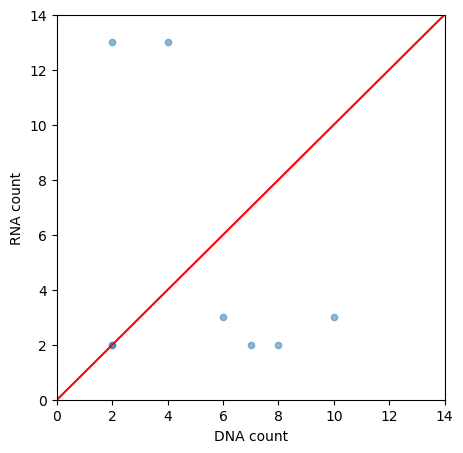

In [81]:
ax1 = numListDf.plot.scatter(x = 'DNA count', y = 'RNA count',figsize = (5,5),alpha = 0.5)
ax1.set_xlim(0,14)
ax1.set_ylim(0,14)
ax1.axline((0, 0), slope=1,color = 'r')
plt.savefig('type2_DNA_RNA_ins_clustered.pdf')

In [82]:
len(set(allDNA))

37

In [83]:
len(allDNA)

193

In [84]:
len(ratioList)

8

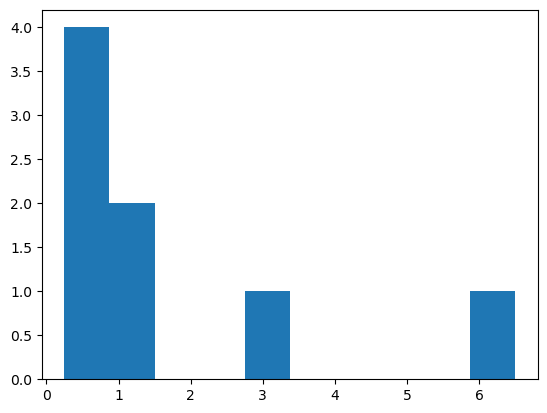

In [85]:
plt.hist(ratioList,bins = 10)
plt.savefig('type2_DNA_RNA_ins_clustered_2.pdf')

In [86]:
simpleInsDic = {}
allSimple = []
for each in commonListGene:
    if each[1] not in allComplex:
        allSimple.append(each[1]+'.'+each[2])
        key = each[5] + '.' + each[4]
        if key in simpleInsDic:
            simpleInsDic[key].append(each)
        else:
            simpleInsDic[key] = [each]

In [87]:
len(set(allSimple))

13

In [88]:
simpleInsDic

{'CFAP298-TCP10L.2655-CB-26': [['21',
   '21:32570937',
   '21:32569194',
   '4752PrimaryT',
   '2655-CB-26',
   'CFAP298-TCP10L'],
  ['21',
   '21:32570937',
   '21:32568437',
   '4752PrimaryT',
   '2655-CB-26',
   'CFAP298-TCP10L'],
  ['21',
   '21:32568437',
   '21:32569194',
   '4752PrimaryT',
   '2655-CB-26',
   'CFAP298-TCP10L'],
  ['21',
   '21:32568437',
   '21:32568437',
   '4752PrimaryT',
   '2655-CB-26',
   'CFAP298-TCP10L']],
 'TCP10L.2655-CB-26': [['21',
   '21:32570937',
   '21:32569194',
   '4752PrimaryT',
   '2655-CB-26',
   'TCP10L'],
  ['21', '21:32570937', '21:32568437', '4752PrimaryT', '2655-CB-26', 'TCP10L'],
  ['21', '21:32568437', '21:32569194', '4752PrimaryT', '2655-CB-26', 'TCP10L'],
  ['21',
   '21:32568437',
   '21:32568437',
   '4752PrimaryT',
   '2655-CB-26',
   'TCP10L']],
 'CFAP298-TCP10L.2655-CB-27': [['21',
   '21:32568437',
   '21:32570937',
   '4752RMT',
   '2655-CB-27',
   'CFAP298-TCP10L'],
  ['21',
   '21:32568437',
   '21:32569194',
   '4752RMT',


In [89]:
dnaList = []
for key in simpleInsDic:
    for each in simpleInsDic[key]:
        dnaList.append(each[2])

In [90]:
len(set(dnaList))

10

In [91]:
ratioListSimple = []
numList = []
for ins in simpleInsDic:
    DNAList = []
    RNAList = []
    for pair in simpleInsDic[ins]:
        DNAList.append(pair[1])
        RNAList.append(pair[2])
    print(ins,set(RNAList))
    print(ins,set(DNAList))
    ratioListSimple.append(len(set(RNAList))/len(set(DNAList)))
    numList.append([len(set(RNAList)),len(set(DNAList))])

CFAP298-TCP10L.2655-CB-26 {'21:32568437', '21:32569194'}
CFAP298-TCP10L.2655-CB-26 {'21:32568437', '21:32570937'}
TCP10L.2655-CB-26 {'21:32568437', '21:32569194'}
TCP10L.2655-CB-26 {'21:32568437', '21:32570937'}
CFAP298-TCP10L.2655-CB-27 {'21:32568437', '21:32569194', '21:32570937'}
CFAP298-TCP10L.2655-CB-27 {'21:32568437', '21:32570937'}
TCP10L.2655-CB-27 {'21:32568437', '21:32569194', '21:32570937'}
TCP10L.2655-CB-27 {'21:32568437', '21:32570937'}
FAS.152-CB-30 {'10:88992648', '10:88992531', '10:88992532', '10:88992747'}
FAS.152-CB-30 {'10:88992756'}
ACTA2.152-CB-30 {'10:88992648', '10:88992531', '10:88992532', '10:88992747'}
ACTA2.152-CB-30 {'10:88992756'}
ENST00000651408.152-CB-30 {'10:88992648', '10:88992531', '10:88992532', '10:88992747'}
ENST00000651408.152-CB-30 {'10:88992756'}
ENST00000620386.152-CB-30 {'10:88992648', '10:88992531', '10:88992532', '10:88992747'}
ENST00000620386.152-CB-30 {'10:88992756'}
ERC1.6670-CB-15 {'12:1371828', '12:1317260', '12:1317288'}
ERC1.6670-CB-15

In [92]:
len(ratioListSimple)

9

In [93]:
numListDf = pd.DataFrame(numList,columns = ['RNA count','DNA count'])

In [94]:
numListDf

,RNA count,DNA count
0,2,2
1,2,2
2,3,2
3,3,2
4,4,1
5,4,1
6,4,1
7,4,1
8,3,1


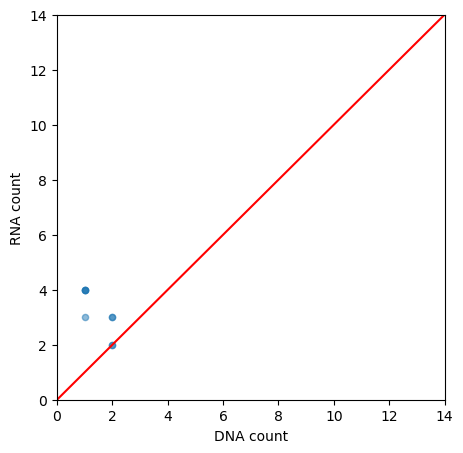

In [95]:
ax1 = numListDf.plot.scatter(x = 'DNA count', y = 'RNA count',figsize = (5,5),alpha = 0.5)
ax1.set_xlim(0,14)
ax1.set_ylim(0,14)
ax1.axline((0, 0), slope=1,color = 'r')
plt.savefig('type1_DNA_RNA_ins_clustered.pdf')

In [96]:
ratioListSimple

[1.0, 1.0, 1.5, 1.5, 4.0, 4.0, 4.0, 4.0, 3.0]

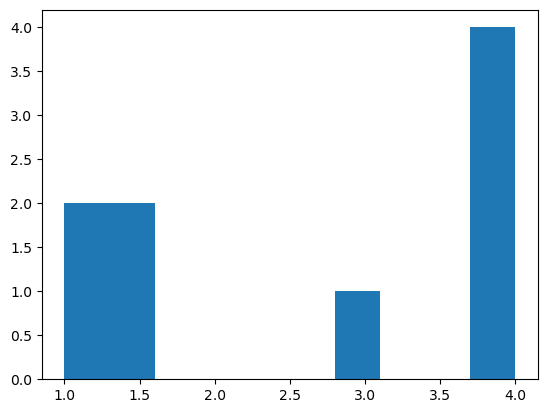

In [97]:
plt.hist(ratioListSimple,bins = 10)
plt.savefig('type1_DNA_RNA_ins_clustered_2.pdf')

In [98]:
sampleInfoDf

,Unnamed: 0,RNA Sample ID,TCS Resp ID,TCS ID,TCS Sample name,Core ng/ul,ul Remaining,Total ng,RIN,DV200,...,iDC,ly Endothelial cells,mv Endothelial cells,naive B-cells,pDC,pro B-cells,ImmuneScore,StromaScore,MicroenvironmentScore,HPV integration type (based on TCS Human Fusion)
0,0,3266-CB-1,3832,HNSpore3832T,83040,474.0,37.0,17538.0,1.4,27.00,...,0.1469,0.0948,0.1407,0.0573,0.0122,0.0041,0.7870,0.1531,0.9400,
1,1,3266-CB-10,4000,HNSpore4000T,83038,61.0,38.0,2318.0,2.3,27.00,...,0.2984,0.1443,0.0969,0.1675,0.2265,0.0566,1.3727,0.2396,1.6124,
2,2,3266-CB-102,SOP-074-B,SOP-074-B,2789-CB-85,71.2,38.0,2706.0,1.7,51.00,...,0.0000,0.0784,0.0376,0.0438,0.0884,0.0882,0.4945,0.1386,0.6332,Type2
3,3,3266-CB-103,SOP-075-A,SOP-075-A,2789-CB-87,107.0,37.0,3959.0,1.0,45.00,...,0.0000,0.0378,0.0687,0.0790,0.1397,0.0126,0.4687,0.1852,0.6539,Type2
4,4,3266-CB-104,SOP-075-B,SOP-075-B,2789-CB-88,67.2,37.0,2486.0,1.8,61.00,...,0.1080,0.0783,0.1396,0.0000,0.1528,0.0388,0.4299,0.1144,0.5442,Type2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,149,5343-CB-2,3173,3173,6670-CB-87,162.0,18.0,2916.0,7.4,93.21,...,0.1209,0.0406,0.0628,0.0867,0.1604,0.0823,0.8028,0.0778,0.8806,Type1
150,150,5343-CB-3,3749,3749,6670-CB-93,170.0,16.0,2720.0,6.7,92.24,...,0.1098,0.0972,0.1168,0.0481,0.0234,0.0298,0.7221,0.1271,0.8493,Type0
151,151,5343-CB-4,2352,2352,6670-CB-88,184.5,18.0,3321.0,4.9,86.42,...,0.0556,0.0498,0.0599,0.0730,0.0386,0.0980,0.3357,0.0548,0.3904,Type0
152,152,5343-CB-5,,,,166.5,18.0,2997.0,5.0,88.70,...,0.0000,0.0275,0.0000,0.0164,0.0000,0.1162,0.1401,0.0088,0.1489,


In [99]:
def extract_distance(sampleInfoDf):
    #distribution of distance of the nearest DNA and RNA integrations
    #reformat the dictionary
    distance_list = []
    i = 0
    for sample in sampleInfoDf['TCS ID']:

        DNASite = sampleInfoDf['TCS Human Fusion'][i]
        RNASite = sampleInfoDf['RNA-seq Human Fusion'][i]
        #compare the two

        for site1 in DNASite.split(';'):
            if site1 != '':
                chro1 = site1.split(':')[0]
                ins1 = site1.split(':')[1]
                delta = 500000000
                sameChro = False
                for site2 in RNASite.split(';'):
                    if site2 != '':
                        chro2 = site2.split(':')[0]
                        ins2 = site2.split(':')[1]
                        if chro1 == chro2:
                            if abs(int(ins1)-int(ins2)) < delta:
                                delta = abs(int(ins1)-int(ins2))
                                sameChro = True
                if sameChro:
                    distance_list.append(delta)
        i += 1
    return distance_list

                
        


In [100]:
distance_df = sampleInfoDf
distance_df = distance_df.reset_index(drop=True)
distance_list = extract_distance(distance_df)

In [101]:
type2_df = sampleInfoDf[sampleInfoDf['HPV integration type (based on TCS Human Fusion)']=='Type2']
type2_df = type2_df.reset_index(drop=True)
type2_distance_list = extract_distance(type2_df)

In [102]:
type1_df = sampleInfoDf[sampleInfoDf['HPV integration type (based on TCS Human Fusion)']=='Type1']
type1_df = type1_df.reset_index(drop=True)
type1_distance_list = extract_distance(type1_df)

In [103]:
type0_df = sampleInfoDf[sampleInfoDf['HPV integration type (based on TCS Human Fusion)']=='Type0']
type0_df = type0_df.reset_index(drop=True)
type0_distance_list = extract_distance(type0_df)

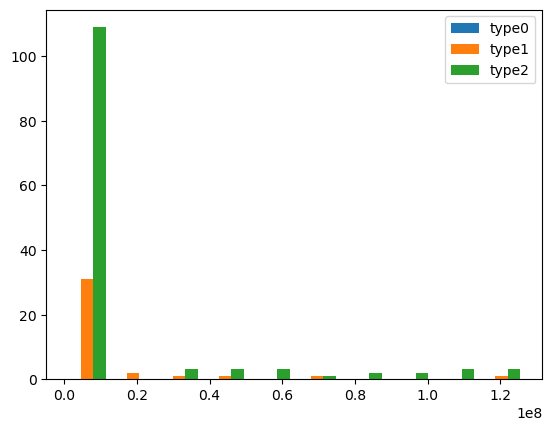

In [104]:
fig,ax = plt.subplots()
ax.hist([type0_distance_list,type1_distance_list,type2_distance_list],bins=10)
ax.legend(labels = ['type0','type1','type2'])

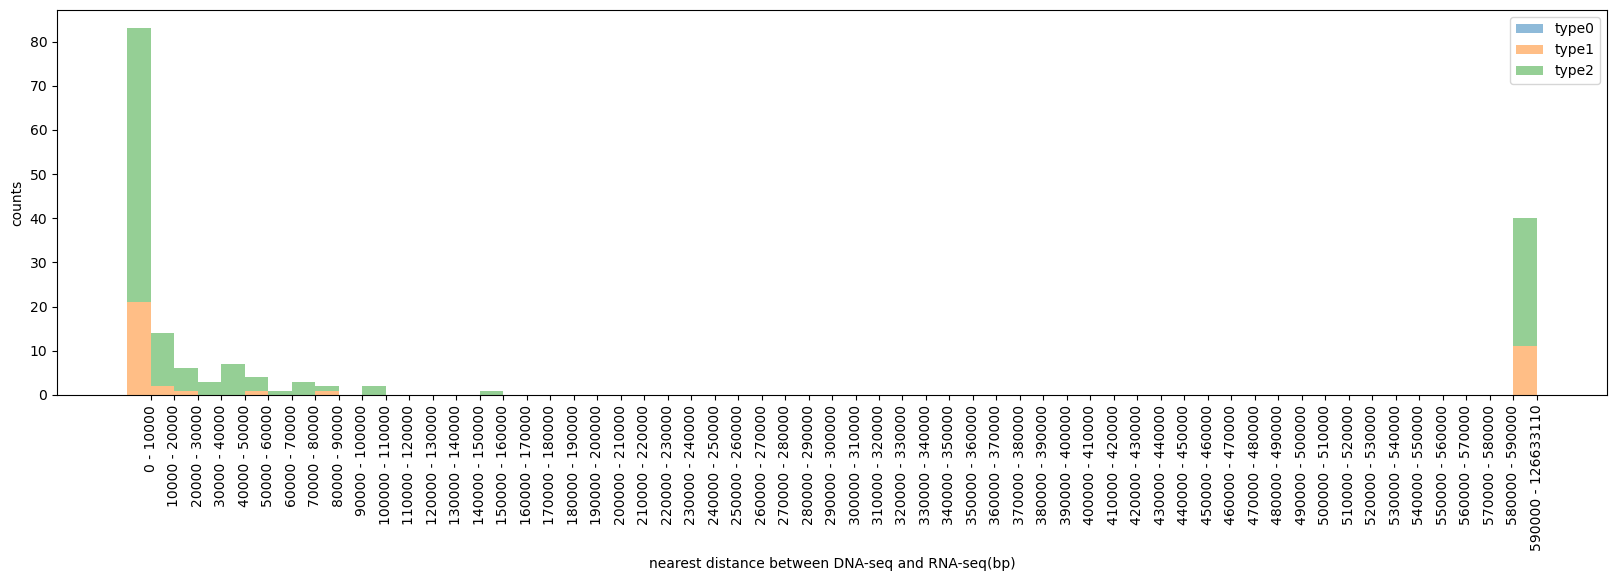

In [105]:
#make breaks

plt.figure(figsize = (20,5))
bins_list = range(0,600000,10000)
bins_list2 = [max(distance_list)]
bins = list(bins_list) + bins_list2
hist, bin_edges = np.histogram(distance_list,bins) 
hist1, bin_edges = np.histogram(type1_distance_list,bins) 
hist2, bin_edges = np.histogram(type2_distance_list,bins) 
hist0, bin_edges = np.histogram(type0_distance_list,bins) 
width = 0
plt.bar(np.arange(len(hist0)),hist0,width=1,alpha = 0.5) 
plt.bar(np.arange(len(hist1))+width,hist1,width=1,alpha = 0.5,bottom=hist0) 
plt.bar(np.arange(len(hist2))+2*width,hist2,width=1,alpha = 0.5,bottom=hist0+hist1) 
plt.xticks([0.5+i for i,j in enumerate(hist)],labels = ['{} - {}'.format(bins[i],bins[i+1]) for i,j in enumerate(hist)])
plt.xticks(rotation = 90)
plt.xlabel('nearest distance between DNA-seq and RNA-seq(bp)')
plt.ylabel('counts')
plt.legend(labels = ['type0','type1','type2'])
plt.xticks(label = ['{} - {}'.format(bins[i],bins[i+1]) for i,j in enumerate(hist)])
plt.savefig('final_table/distance_types.png')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
        33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5, 43.5,
        44.5, 45.5, 46.5, 47.5, 48.5, 49.5, 50.5, 51.5, 52.5, 53.5, 54.5,
        55.5, 56.5, 57.5, 58.5, 59.5]),
 [Text(0.5, 0, '0 - 10000'),
  Text(1.5, 0, '10000 - 20000'),
  Text(2.5, 0, '20000 - 30000'),
  Text(3.5, 0, '30000 - 40000'),
  Text(4.5, 0, '40000 - 50000'),
  Text(5.5, 0, '50000 - 60000'),
  Text(6.5, 0, '60000 - 70000'),
  Text(7.5, 0, '70000 - 80000'),
  Text(8.5, 0, '80000 - 90000'),
  Text(9.5, 0, '90000 - 100000'),
  Text(10.5, 0, '100000 - 110000'),
  Text(11.5, 0, '110000 - 120000'),
  Text(12.5, 0, '120000 - 130000'),
  Text(13.5, 0, '130000 - 140000'),
  Text(14.5, 0, '140000 - 150000'),
  Text(15.5, 0, '150000 - 160000'),
  Text(16.5, 0, '160000 - 170000'),
  Text(17.5

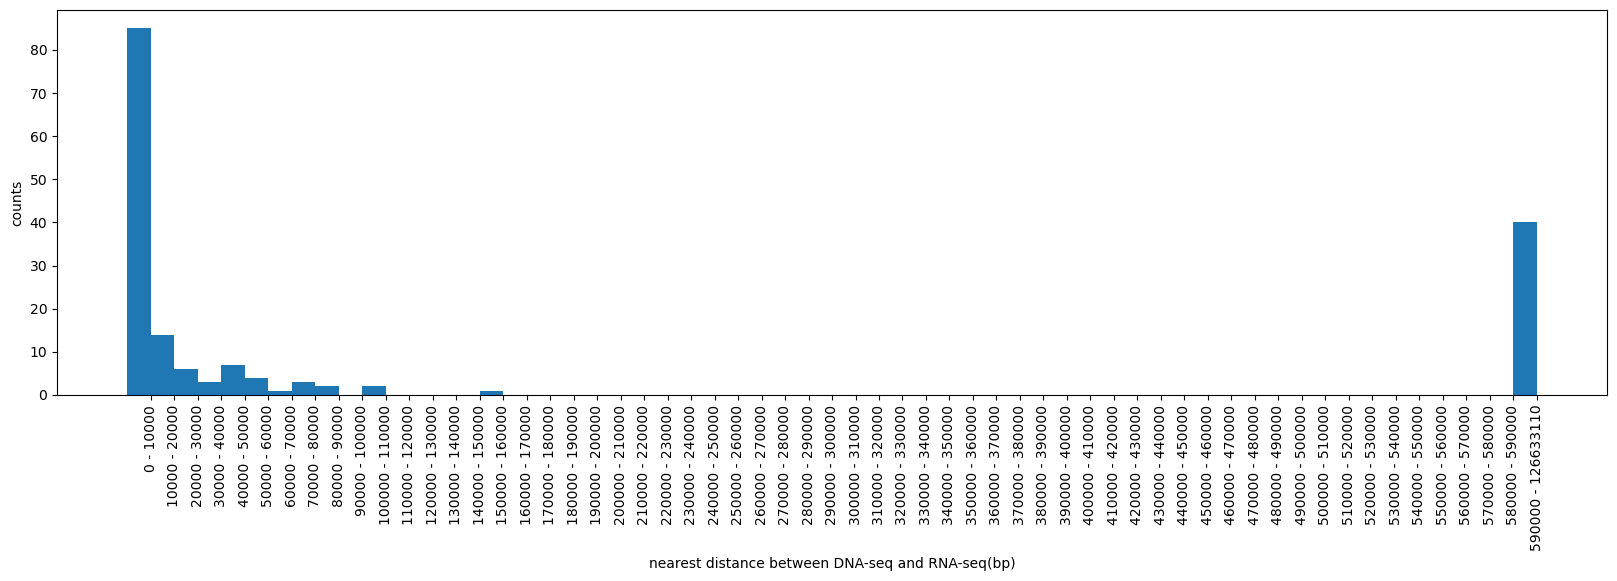

In [106]:
#make breaks

plt.figure(figsize = (20,5))
bins_list = range(0,600000,10000)
bins_list2 = [max(distance_list)]
bins = list(bins_list) + bins_list2
hist, bin_edges = np.histogram(distance_list,bins) 
plt.bar(range(len(hist)),hist,width=1) 
plt.xticks([0.5+i for i,j in enumerate(hist)],labels = ['{} - {}'.format(bins[i],bins[i+1]) for i,j in enumerate(hist)])
plt.xticks(rotation = 90)
plt.xlabel('nearest distance between DNA-seq and RNA-seq(bp)')
plt.ylabel('counts')
plt.xticks(label = ['{} - {}'.format(bins[i],bins[i+1]) for i,j in enumerate(hist)])

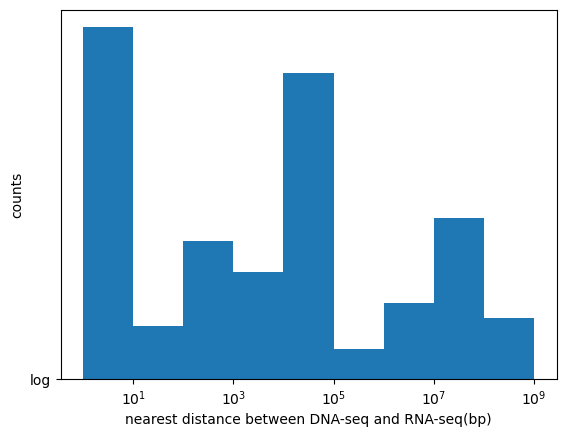

<Figure size 2000x500 with 0 Axes>

In [107]:
fig, ax = plt.subplots()
plt.figure(figsize = (20,5))
ax.hist([x + 1 for x in distance_list],bins = 10**(np.arange(0,10))) 
ax.ticklabel_format(style='plain')
ax.set_xticks(range(0,max(distance_list),1000000))
#plt.xticks(rotation = 90)
ax.set_xlabel('nearest distance between DNA-seq and RNA-seq(bp)')
ax.set_ylabel('counts')
ax.semilogx("log")

In [108]:
max(distance_list)

126633110

In [109]:
resDicHPV = {}
j = 0
for sampleID in sampleInfoDf['RNA Sample ID']:
    sample = 'Sample_' + sampleID
    i = 0
    resList = []
    for ins in sampleInfoDf['RNA-seq Human Fusion'][j].split(';'):
        if ins != '':
            chro = ins.split(':')[0]
            newIns = ins.split(':')[1]
            hpv = str(sampleInfoDf['RNA-seq HPV Fusion'][j]).split(';')[i]
            resList.append(chro + '.' + str(newIns) + '.' + str(hpv))
        i += 1
    j += 1
        
    if resList != []:    
        resDicHPV[sample] = list(set(resList))


In [110]:
resDicHPV

{'Sample_3266-CB-102': ['2.38486630.880'],
 'Sample_3266-CB-103': ['19.45007892.4396'],
 'Sample_3266-CB-107': ['16.11254951.2038',
  '9.13738650.880',
  '9.13730514.2517',
  '9.13730863.880',
  '16.11249762.881'],
 'Sample_3266-CB-146': ['9.123319502.2772',
  '9.123319515.1767',
  '9.123328690.3027',
  '9.123342472.880'],
 'Sample_3266-CB-182': ['5.23988715.3388',
  '5.23993891.2302',
  '5.23993885.2293',
  '5.23988527.228',
  '5.23988714.3355',
  '5.23988526.882'],
 'Sample_3266-CB-183': ['5.23993885.2293',
  '5.23993891.2302',
  '5.23988714.3355',
  '5.23988526.882'],
 'Sample_3266-CB-19': ['9.138279657.2567'],
 'Sample_3266-CB-20': ['Y.19571696.4073',
  '9.5423555.2778',
  '9.5422685.5514',
  'Y.19569045.6452'],
 'Sample_3266-CB-259': ['3.27713411.882',
  '3.27712807.3455',
  '3.27712159.227',
  '3.27711686.226',
  '3.27712158.881',
  '3.27713413.228',
  '3.27711685.880',
  '3.27712429.3991',
  '3.27705191.1065',
  '3.27716533.2554',
  '3.27713068.3212',
  '3.27712322.3356',
  '3.2

In [111]:
sampleDNADf = pd.read_csv('../sup_1/Sup_0_hpv16_sheet.csv')

In [112]:
sampleDNADf.columns.to_list()

['Unnamed: 0',
 'ID',
 'SeqID_Tumor',
 'HPV type ',
 'Num HPV Integration',
 'HPV integration',
 'HPV integration breakpoints on HPV genome',
 'Total # Host Genes with integration',
 'Host Genes with integration',
 'Integrated in at least 1 human gene',
 'Integrated in at least 1 human cancer gene (COSMIC Teir1/2)',
 'Integrated in at least 1 human cancer gene (COSMIC Teir1/2); Gene Name',
 'At least 1 integration is a type2 structure',
 '# of E2 Breakpoints']

In [113]:
dnaResDic = {}
j = 0
for sampleID in sampleDNADf['SeqID_Tumor']:
    sample = 'Sample_' + str(sampleID)
    
    resList = []
    if pd.notna(sampleDNADf['HPV integration'][j]):
        i = 0
        for ins in sampleDNADf['HPV integration'][j].split(';'):
            if ins != '':
                chro = ins.split(':')[0].replace('chr','')
                newIns = ins.split(':')[1]
                hpv = sampleDNADf['HPV integration breakpoints on HPV genome'][j].split(';')[i]
                resList.append(chro + '.' + str(newIns) + '.' + str(hpv))
            i += 1
    j += 1
        
    if resList != []:    
        dnaResDic[sample] = list(set(resList))


In [114]:
dnaResDic

{'Sample_83026': ['3.93470451.6791,7405',
  '6.76536017.7356',
  '8.63451898.1745',
  '8.120080943.6584',
  '3.93470774.6791,7405',
  '3.54562145.893',
  '11.84777199.4925',
  '16.25541381.4184',
  '12.91944711.4700,1149'],
 'Sample_83030': ['15.26038251.4414',
  '8.3990025.2128',
  '3.93470784.2480',
  '8.3866216.3233',
  '3.144105587.1347',
  '12.76962150.3916',
  '10.105009500.4357',
  '14.106781925.2249',
  '3.93470586.2480'],
 'Sample_83034': ['6.34844401.1434',
  '6.34843583.1433',
  '11.56835917.6989',
  '8.100385068.5453,1937'],
 'Sample_83044': ['9.68582624.6264',
  '10.31032491.996',
  '20.48179686.7116',
  '17.57662300.7105',
  '7.42649195.6874',
  '2.8593725.7239',
  '6.114064443.3913',
  '3.93470677.980',
  '2.71596007.3281',
  '2.123546273.2557',
  '11.5149320.5060',
  '3.178906370.3047',
  '3.93470393.980',
  '13.22775305.972',
  '2.186995465.5778'],
 'Sample_83048': ['17.82263199.2159',
  '3.78853185.2110',
  '14.65554627.1344',
  '11.21407740.1400'],
 'Sample_83060': [

In [115]:
sampleConvertDic = {}
i = 0
for sample_rna in sampleInfoDf['RNA Sample ID']:
    sampleConvertDic['Sample_' + sample_rna] = 'Sample_' + str(sampleInfoDf['TCS Sample name'][i])
    i += 1

In [116]:
sampleConvertDic

{'Sample_3266-CB-1': 'Sample_83040',
 'Sample_3266-CB-10': 'Sample_83038',
 'Sample_3266-CB-102': 'Sample_2789-CB-85',
 'Sample_3266-CB-103': 'Sample_2789-CB-87',
 'Sample_3266-CB-104': 'Sample_2789-CB-88',
 'Sample_3266-CB-106': 'Sample_2789-CB-91',
 'Sample_3266-CB-107': 'Sample_2789-CB-94',
 'Sample_3266-CB-108': 'Sample_2789-CB-95',
 'Sample_3266-CB-109': 'Sample_2789-CB-96',
 'Sample_3266-CB-110': 'Sample_126435',
 'Sample_3266-CB-12': 'Sample_83044',
 'Sample_3266-CB-146': 'Sample_109332',
 'Sample_3266-CB-15': 'Sample_83050',
 'Sample_3266-CB-18': 'Sample_83058',
 'Sample_3266-CB-180': 'Sample_',
 'Sample_3266-CB-182': 'Sample_2920-CB-19',
 'Sample_3266-CB-183': 'Sample_2920-CB-20',
 'Sample_3266-CB-189': 'Sample_2920-CB-28',
 'Sample_3266-CB-19': 'Sample_83060',
 'Sample_3266-CB-20': 'Sample_83062',
 'Sample_3266-CB-206': 'Sample_',
 'Sample_3266-CB-207': 'Sample_',
 'Sample_3266-CB-21': 'Sample_83064',
 'Sample_3266-CB-211': 'Sample_2920-CB-38',
 'Sample_3266-CB-212': 'Sample_

In [117]:
#compare integrations, exact same integrations
commonDic = {}
for sample in resDicHPV:
    if sample in sampleConvertDic:
        #print(sampleConvertDic[sample])
        #in complex sample, see if in complex structures
        if sampleConvertDic[sample] in dnaResDic:
            for site2 in resDicHPV[sample]:
                for site1 in dnaResDic[sampleConvertDic[sample]]:
                    if site1 != [] and site2 != []:
                        
                        chro = site1.split('.')[0]
                        ins = int(site1.split('.')[1])
                        chro2 = site2.split('.')[0]
                        ins2 = int(site2.split('.')[1])
#                         print("site1",site1)
#                         print("site2",site2)
                        if str(chro) == str(chro2) and int(ins) >= int(ins2)-10 and int(ins) <= int(ins2) + 10:
                            if sample in commonDic:
                                commonDic[sample].append([site1,site2])
                            else:
                                commonDic[sample] = [[site1,site2]]

In [118]:
commonDic

{'Sample_3266-CB-20': [['Y.19571696.4073', 'Y.19571696.4073'],
  ['9.5423555.2778', '9.5423555.2778'],
  ['9.5422685.5514,2857', '9.5422685.5514'],
  ['Y.19569045.6452', 'Y.19569045.6452']],
 'Sample_3266-CB-259': [['3.27705191.1065', '3.27705191.1065'],
  ['3.27716533.2554', '3.27716533.2554'],
  ['3.27713068.3212', '3.27713068.3212'],
  ['3.27721327.3047', '3.27721327.3047']],
 'Sample_3266-CB-267': [['3.178033809.2237', '3.178033809.2237'],
  ['7.91067077.2914,809', '7.91067077.809'],
  ['3.178053238.2643', '3.178053238.2643'],
  ['7.90977852.964', '7.90977852.964']],
 'Sample_3266-CB-29': [['1.242015319.1729', '1.242015319.1729']],
 'Sample_3266-CB-300': [['21.43770620.6232,4089', '21.43770620.6232']],
 'Sample_3266-CB-302': [['21.32568437.1160', '21.32568437.1160']],
 'Sample_3266-CB-316': [['12.6516855.3438', '12.6516855.3722'],
  ['12.6352390.5045', '12.6352390.5045'],
  ['X.53189882.6965', 'X.53189882.6965'],
  ['X.53194820.3770', 'X.53194820.3770'],
  ['12.6391184.3395', '12.6

In [119]:
i = 0
for sample in commonDic:
    i += len(commonDic[sample])
print(i)

33


In [120]:
#compare integrations, for clustered integrations, within +/- 50kbp, for single integrations, within  +/- 10bp integrations
#cluster two datasets
clusteredSite = {}
clusteredDNAComplexRes = {}
for sample in dnaResDic:
    #cluster site within 500kb
    dnaList = dnaResDic[sample]
    clusteredSite[sample] = {}
    clusteredDNAComplexRes[sample] = {}
    if dnaList != []:
        for each in dnaList:
            chro1 = each.split('.')[0]
            ins1 = int(each.split('.')[1])
            if chro1 in clusteredSite[sample]:
                clusteredSite[sample][chro1].append(ins1)
            else:
                clusteredSite[sample][chro1] = [ins1]
        for eachChro in clusteredSite[sample]:
            #print(clusteredSite[sample][eachChro])
            a = np.array(clusteredSite[sample][eachChro])
            #print(a)
            a = sorted(clusteredSite[sample][eachChro])
            deltaList = [0]
            for i in range(len(a)-1):
                deltaList.append(abs(a[i+1]-a[i]))
            cutList = []
            for i in range(len(deltaList)):
                if deltaList[i] > 500000:
                    cutList.append(i)
            #print(cutList)
            if cutList != []:
                clusteredDNAComplexRes[sample][eachChro] = [a[0:cutList[0]],a[cutList[-1]:]]#add the first and last slots
                for i in range(len(cutList)-1):
                    clusteredDNAComplexRes[sample][eachChro].append(a[cutList[i]:cutList[i+1]])
            else:
                clusteredDNAComplexRes[sample][eachChro] = [a]
clusteredDNAComplexResNew = {}
for sample in clusteredDNAComplexRes:
    clusteredDNAComplexResNew[sample] = {}
    for chro in clusteredDNAComplexRes[sample]:
        for cluster in clusteredDNAComplexRes[sample][chro]:
            if chro in clusteredDNAComplexResNew[sample]:
                clusteredDNAComplexResNew[sample][chro].append(list(set(cluster)))
            else:
                clusteredDNAComplexResNew[sample][chro] = [list(set(cluster))]
                                                         



In [121]:
clusteredSite = {}
clusteredRNAComplexRes = {}
for sample in resDicHPV:
    #cluster site within 500kb
    RNAList = resDicHPV[sample]
    clusteredSite[sample] = {}
    clusteredRNAComplexRes[sample] = {}
    if RNAList != []:
        for each in RNAList:
            chro1 = each.split('.')[0]
            ins1 = int(each.split('.')[1])
            
            if chro1 in clusteredSite[sample]:
                clusteredSite[sample][chro1].append(ins1)
            else:
                clusteredSite[sample][chro1] = [ins1]
        for eachChro in clusteredSite[sample]:
            #print(clusteredSite[sample][eachChro])
            a = np.array(clusteredSite[sample][eachChro])
            #print(a)
            a = sorted(clusteredSite[sample][eachChro])
            deltaList = [0]
            for i in range(len(a)-1):
                deltaList.append(abs(a[i+1]-a[i]))
            cutList = []
            for i in range(len(deltaList)):
                if deltaList[i] > 500000:
                    cutList.append(i)
            #print(cutList)
            if cutList != []:
                clusteredRNAComplexRes[sample][eachChro] = [a[0:cutList[0]],a[cutList[-1]:]]#add the first and last slots
                for i in range(len(cutList)-1):
                    clusteredRNAComplexRes[sample][eachChro].append(a[cutList[i]:cutList[i+1]])
            else:
                clusteredRNAComplexRes[sample][eachChro] = [a]
clusteredRNAComplexResNew = {}
for sample in clusteredRNAComplexRes:
    clusteredRNAComplexResNew[sample] = {}
    for chro in clusteredRNAComplexRes[sample]:
        for cluster in clusteredRNAComplexRes[sample][chro]:
            if chro in clusteredRNAComplexResNew[sample]:
                clusteredRNAComplexResNew[sample][chro].append(list(set(cluster)))
            else:
                clusteredRNAComplexResNew[sample][chro] = [list(set(cluster))]
                                                         
    

In [122]:
##compare integrations, for clustered integrations, within +/- 50kbp, for single integrations, within  +/- 10bp integrations
clusterCommonDic = {}
for sample in clusteredRNAComplexResNew:
    if sample in sampleConvertDic:
        #print(sampleConvertDic[sample])
        #in complex sample, see if in complex structures
        if sampleConvertDic[sample] in clusteredDNAComplexResNew:
            clusterCommonDic[sample] = {}
            for chro2 in clusteredRNAComplexResNew[sample]:
                for chro1 in clusteredDNAComplexResNew[sampleConvertDic[sample]]:
                    if chro1 == chro2:
                        for siteList1 in clusteredRNAComplexResNew[sample][chro1]:
                            for siteList2 in  clusteredDNAComplexResNew[sampleConvertDic[sample]][chro2]:
                                if len(siteList1) == 1 and len(siteList2) == 1:
                                    print(siteList1,siteList2)
                                    ins = int(siteList1[0])
                                    ins2 = int(siteList2[0])
                                    if int(ins) >= int(ins2)-10 and int(ins) <= int(ins2) + 10:
                                        if chro1 in clusterCommonDic[sample]:
                                            clusterCommonDic[sample][chro1].append([[site1],[site2]])
                                        else:
                                            clusterCommonDic[sample][chro1] = [[[site1],[site2]]]
                                else:            
                                    if max(siteList1) < min(siteList2) and min(siteList2) - max(siteList1) < 50000:
                                        if chro1 in clusterCommonDic[sample]:
                                            clusterCommonDic[sample][chro1].append([siteList1,siteList2])
                                        else:
                                            clusterCommonDic[sample][chro1] = [[siteList1,siteList2]]
                                    if max(siteList2) < min(siteList1) and min(siteList1) - max(siteList2) < 50000:
                                        if chro1 in clusterCommonDic[sample]:
                                            clusterCommonDic[sample][chro1].append([siteList1,siteList2])
                                        else:
                                            clusterCommonDic[sample][chro1] = [[siteList1,siteList2]]
                                    #overlap        
                                    if max(siteList2) > min(siteList1) and max(siteList1) > max(siteList2):
                                        if chro1 in clusterCommonDic[sample]:
                                            clusterCommonDic[sample][chro1].append([siteList1,siteList2])
                                        else:
                                            clusterCommonDic[sample][chro1] = [[siteList1,siteList2]]
                                    if max(siteList1) > min(siteList2) and max(siteList1) < max(siteList2):
                                        if chro1 in clusterCommonDic[sample]:
                                            clusterCommonDic[sample][chro1].append([siteList1,siteList2])
                                        else:
                                            clusterCommonDic[sample][chro1] = [[siteList1,siteList2]]



[45007892] [43544513]
[45007892] [46026128]
[51202030] [51150146]


In [123]:
len(clusterCommonDic)

21

In [124]:
clusterCommonDic

{'Sample_3266-CB-102': {},
 'Sample_3266-CB-103': {},
 'Sample_3266-CB-146': {},
 'Sample_3266-CB-19': {},
 'Sample_3266-CB-20': {'9': [[[5423555, 5422685],
    [5447557,
     5379722,
     5339915,
     5457041,
     5468947,
     5349786,
     5425057,
     5393316,
     5470002,
     5466675,
     5470644,
     5441465,
     5485117,
     5423555,
     5454661,
     5445702,
     5441235,
     5422685,
     5365469,
     5493998,
     5483254,
     5477245]]]},
 'Sample_3266-CB-259': {'3': [[[27712322,
     27713411,
     27711685,
     27711686,
     27705191,
     27712807,
     27713413,
     27713068,
     27712429,
     27721327,
     27716533,
     27712158,
     27712159],
    [27705191, 27713068, 27721327, 27716533, 27722807, 27733597]]]},
 'Sample_3266-CB-267': {'7': [[[91067089, 90979995, 90977852, 91067077],
    [90979913, 90977852, 91067077, 91067446]]],
  '3': [[[178033809, 178053238, 178029607],
    [178071520,
     178067939,
     178033606,
     177981230,
     17802

In [125]:
i = 0
j = 0
k = 0
m = 0
numClusterDNA = []
numClusterRNA = []
for sample in clusterCommonDic:
    if clusterCommonDic[sample] != {}:
        m += 1
        for chro in clusterCommonDic[sample]:
            #print(len(clusterCommonDic[sample][chro]))
            i += len(clusterCommonDic[sample][chro])
            for cluster in clusterCommonDic[sample][chro]:
                #RNA
                j += len(cluster[0])
                print(cluster[0])
                numClusterRNA.append(len(cluster[0]))
                #DNA
                k += len(cluster[1])
                numClusterDNA.append(len(cluster[1]))
print(m)
print(i)
print(j)
print(k)

[5423555, 5422685]
[27712322, 27713411, 27711685, 27711686, 27705191, 27712807, 27713413, 27713068, 27712429, 27721327, 27716533, 27712158, 27712159]
[91067089, 90979995, 90977852, 91067077]
[178033809, 178053238, 178029607]
[242007630, 242003357, 241999030, 242015319]
[32569194, 32568437]
[88992648, 88992531, 88992532, 88992747]
[43915275, 43911556, 43874931, 43911555]
[52882240, 52939785, 52939786, 52894162, 52926514, 52893716, 52882806]
[189811288, 189811297]
[59838884, 59838701, 59838398, 59839766]
[97793497, 97795803]
[48087920, 48087910]
11
13
53
80


In [126]:
dnaResDic

{'Sample_83026': ['3.93470451.6791,7405',
  '6.76536017.7356',
  '8.63451898.1745',
  '8.120080943.6584',
  '3.93470774.6791,7405',
  '3.54562145.893',
  '11.84777199.4925',
  '16.25541381.4184',
  '12.91944711.4700,1149'],
 'Sample_83030': ['15.26038251.4414',
  '8.3990025.2128',
  '3.93470784.2480',
  '8.3866216.3233',
  '3.144105587.1347',
  '12.76962150.3916',
  '10.105009500.4357',
  '14.106781925.2249',
  '3.93470586.2480'],
 'Sample_83034': ['6.34844401.1434',
  '6.34843583.1433',
  '11.56835917.6989',
  '8.100385068.5453,1937'],
 'Sample_83044': ['9.68582624.6264',
  '10.31032491.996',
  '20.48179686.7116',
  '17.57662300.7105',
  '7.42649195.6874',
  '2.8593725.7239',
  '6.114064443.3913',
  '3.93470677.980',
  '2.71596007.3281',
  '2.123546273.2557',
  '11.5149320.5060',
  '3.178906370.3047',
  '3.93470393.980',
  '13.22775305.972',
  '2.186995465.5778'],
 'Sample_83048': ['17.82263199.2159',
  '3.78853185.2110',
  '14.65554627.1344',
  '11.21407740.1400'],
 'Sample_83060': [

In [127]:
clusterByGeneDNA = {}
for sample in dnaResDic:
    if sample in sampleConvertDic.values():
        for site in dnaResDic[sample]:
            chro = site.split('.')[0]
            ins = site.split('.')[1]
            hpvBreaks = site.split('.')[2].split(',')
            for hpvBreak in hpvBreaks:
                flag = False
                for gene in geneDic:
                    if chro == geneDic[gene][1] and \
                    int(ins) > int(geneDic[gene][2]) - 5000 and int(ins) < int(geneDic[gene][3]) + 5000:
                        geneName = geneDic[gene][0]
                        if geneName in clusterByGeneDNA:
                            clusterByGeneDNA[geneName].append([chro + '.' + ins + '.' + str(hpvBreak), sample])
                        else:
                            clusterByGeneDNA[geneName] = [[chro + '.' + ins + '.' + str(hpvBreak), sample]]
                        flag = True
                if flag == False:
                    geneName = "intergenic"
                    if geneName in clusterByGeneDNA:
                        clusterByGeneDNA[geneName].append([chro + '.' + ins + '.' + str(hpvBreak), sample])
                    else:
                        clusterByGeneDNA[geneName] = [[chro + '.' + ins + '.' + str(hpvBreak), sample]]


In [128]:
clusterByGeneDNA['NCAPD2']

[['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6507494.1955', 'Sample_2655-CB-57'],
 ['12.6516855.3438', 'Sample_2655-CB-57'],
 ['12.6516855.3438', 'Sample_2655-CB-57'],
 ['12.6516855.3438', 'Sample_2655-CB-57'],
 ['12.6516855.3438', 'Sample_2655-CB-57'],
 ['12.6516855.3438', 'Sample_2655-CB-57'],
 ['12.6516855.3438', 'Sample_2655-CB-57']]

In [129]:
clusterByGeneRNA = {}
for sample in resDicHPV:
    for site in resDicHPV[sample]:
        chro = site.split('.')[0]
        ins = site.split('.')[1]
        flag = False
        for gene in geneDic:
            if chro == geneDic[gene][1] and \
            int(ins) > int(geneDic[gene][2]) - 5000 and int(ins) < int(geneDic[gene][3]) + 5000:
                geneName = geneDic[gene][0]
                if geneName in clusterByGeneRNA:
                    clusterByGeneRNA[geneName].append([site,sample])
                else:
                    clusterByGeneRNA[geneName] = [[site,sample]]
                flag = True
        if flag == False:
            geneName = "intergenic"
            if geneName in clusterByGeneRNA:
                clusterByGeneRNA[geneName].append([site,sample])
            else:
                clusterByGeneRNA[geneName] = [[site,sample]]
                

In [130]:
clusterByGeneRNA

{'LINC02613': [['2.38486630.880', 'Sample_3266-CB-102'],
  ['2.38486630.880', 'Sample_3266-CB-102'],
  ['2.38486630.880', 'Sample_3266-CB-102'],
  ['2.38486630.880', 'Sample_3266-CB-102'],
  ['2.38486630.880', 'Sample_3266-CB-102'],
  ['2.38486630.880', 'Sample_3266-CB-102'],
  ['2.38486630.880', 'Sample_3266-CB-102'],
  ['2.38486630.880', 'Sample_3266-CB-102']],
 'RPLP0P6': [['2.38486630.880', 'Sample_3266-CB-102']],
 'RELB': [['19.45007892.4396', 'Sample_3266-CB-103'],
  ['19.45007892.4396', 'Sample_3266-CB-103'],
  ['19.45007892.4396', 'Sample_3266-CB-103'],
  ['19.45007892.4396', 'Sample_3266-CB-103']],
 'RMI2': [['16.11254951.2038', 'Sample_3266-CB-107'],
  ['16.11254951.2038', 'Sample_3266-CB-107'],
  ['16.11254951.2038', 'Sample_3266-CB-107'],
  ['16.11249762.881', 'Sample_3266-CB-107'],
  ['16.11249762.881', 'Sample_3266-CB-107'],
  ['16.11249762.881', 'Sample_3266-CB-107']],
 'SOCS1': [['16.11254951.2038', 'Sample_3266-CB-107'],
  ['16.11254951.2038', 'Sample_3266-CB-107'],
  

In [131]:
clusteredCount = 0
singleCount = 0

for gene in clusterByGeneDNA:
    if gene != 'intergenic':
        uniqueSiteList = []
        for each in clusterByGeneDNA[gene]:
            uniqueSiteList.append(each[0] + ':' + each[1])
        if len(set(uniqueSiteList)) > 1:
            clusteredCount += 1
        else:
            singleCount += 1

In [132]:
clusteredCount

110

In [133]:
singleCount

1043

In [134]:
clusteredCount = 0
singleCount = 0

for gene in clusterByGeneRNA:
    if gene != 'intergenic':
        uniqueSiteList = []
        for each in clusterByGeneRNA[gene]:
            uniqueSiteList.append(each[0] + ':' + each[1])
        if len(set(uniqueSiteList)) > 1:
            clusteredCount += 1
        else:
            singleCount += 1

In [135]:
clusteredCount

44

In [136]:
singleCount

36

In [137]:
clusterByGeneDNA

{'intergenic': [['3.93470451.6791', 'Sample_83026'],
  ['3.93470451.7405', 'Sample_83026'],
  ['3.93470774.6791', 'Sample_83026'],
  ['3.93470774.7405', 'Sample_83026'],
  ['16.25541381.4184', 'Sample_83026'],
  ['12.91944711.4700', 'Sample_83026'],
  ['12.91944711.1149', 'Sample_83026'],
  ['3.93470784.2480', 'Sample_83030'],
  ['3.144105587.1347', 'Sample_83030'],
  ['12.76962150.3916', 'Sample_83030'],
  ['14.106781925.2249', 'Sample_83030'],
  ['3.93470586.2480', 'Sample_83030'],
  ['20.48179686.7116', 'Sample_83044'],
  ['7.42649195.6874', 'Sample_83044'],
  ['3.93470677.980', 'Sample_83044'],
  ['2.123546273.2557', 'Sample_83044'],
  ['3.93470393.980', 'Sample_83044'],
  ['13.22775305.972', 'Sample_83044'],
  ['2.186995465.5778', 'Sample_83044'],
  ['8.122236223.4585', 'Sample_83060'],
  ['3.93470457.904', 'Sample_83060'],
  ['3.93470457.1253', 'Sample_83060'],
  ['10.9611308.5264', 'Sample_83060'],
  ['13.21906614.5115', 'Sample_83060'],
  ['11.36863415.456', 'Sample_83060'],
  

In [138]:
test_list = []
for each in clusterByGeneRNA['intergenic']:
    test_list.append(each[0])

In [139]:
#compare RNA and DNA
CommonSiteDNA = {}
for gene in clusterByGeneRNA:
    if gene in clusterByGeneDNA:
        if gene != 'intergenic':
            for each1 in clusterByGeneRNA[gene]:
                for each2 in clusterByGeneDNA[gene]:
                    sample1 = each1[1]
                    sample2 = each2[1]
                    if sample1 in sampleConvertDic:
                        if sampleConvertDic[sample1] == sample2:
                            if gene in CommonSiteDNA:
                                CommonSiteDNA[gene].append(each1[0]+ ':'+each2[0] + ':' + each1[1])
                            else:
                                CommonSiteDNA[gene] = [each1[0] + ':' + each2[0]+ ':' + each1[1]]
                            
        else:
            for each1 in clusterByGeneRNA[gene]:
                for each2 in clusterByGeneDNA[gene]:
                    sample1 = each1[1]
                    sample2 = each2[1]
                    if sample1 in sampleConvertDic:
                        if sampleConvertDic[sample1] == sample2:
                            chro1 = each1[0].split('.')[0]
                            site1 = each1[0].split('.')[1]
                            chro2 = each2[0].split('.')[0]
                            site2 = each2[0].split('.')[1]
                            #print(chro1,chro2)
                            if chro1 == chro2 and int(site1) >= int(site2)-100 and int(site1) <= int(site2) + 100:
                                if 'intergenic' in CommonSiteDNA:
                                    CommonSiteDNA['intergenic'].append(each1[0] + ':' + each2[0]+ ':' + each1[1])
                                else:
                                    CommonSiteDNA['intergenic'] = [each1[0] + ':' + each2[0]+ ':' + each1[1]]
                                
            
        
    else:
        print('no such',gene)

no such LINC02613
no such RPLP0P6
no such RELB
no such RMI2
no such SOCS1
no such ENST00000674109
no such ENST00000673752
no such BHLHE40
no such BHLHE40-AS1
no such MAP1LC3C
no such PDXK
no such ENST00000626421
no such HSF2BP
no such RPL31P1
no such GATD3A
no such ENST00000645813
no such WWOX
no such ENST00000563230
no such RAD51B
no such NRG2
no such ENST00000504413
no such STXBP5-AS1
no such ADGB
no such TRAF3
no such KATNBL1P6
no such HDGF
no such PRCC
no such ENST00000661978
no such CCDC122
no such ENST00000613918
no such LACC1
no such GSTA10P
no such GSTA9P
no such TANGO6
no such FDCSP
no such CSN3
no such LINC01206
no such TPRG1
no such NTN1
no such ENST00000508565
no such ZNF123P


In [140]:
CommonSiteDNAUniq = {}
for each in CommonSiteDNA:
    CommonSiteDNAUniq[each] = list(set(CommonSiteDNA[each]))
    

In [141]:
CommonSiteDNAUniq

{'intergenic': ['4.73801521.1256:4.73801521.1256:Sample_5170-CB-16',
  '12.91944711.1149:12.91944711.1149:Sample_3266-CB-4',
  '12.91944711.1149:12.91944711.4700:Sample_3266-CB-4',
  '6.52926514.2487:6.52926514.2487:Sample_3266-CB-49',
  '1.242015319.1729:1.242015319.1729:Sample_3266-CB-29'],
 'BCORP1': ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20',
  'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20',
  'Y.19571696.4073:Y.19569045.6452:Sample_3266-CB-20',
  'Y.19571696.4073:Y.19571696.4073:Sample_3266-CB-20'],
 'TXLNGY': ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20',
  'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20',
  'Y.19571696.4073:Y.19569045.6452:Sample_3266-CB-20',
  'Y.19571696.4073:Y.19571696.4073:Sample_3266-CB-20'],
 'PLGRKT': ['9.5423555.2778:9.5365469.6560:Sample_3266-CB-20',
  '9.5423555.2778:9.5425057.2342:Sample_3266-CB-20',
  '9.5422685.5514:9.5422685.2857:Sample_3266-CB-20',
  '9.5423555.2778:9.5422685.2857:Sample_3266-CB-20',
  '9.5422685.5514:9.53

In [142]:
dnaCount = []
rnaCount = []
sampleList = []
geneList = []
for gene in CommonSiteDNAUniq:
    if gene != 'intergenic':
        for site in CommonSiteDNAUniq[gene]:
            rnaCount.append(site.split(':')[0])
            dnaCount.append(site.split(':')[1])
            sampleList.append(site.split(':')[2])
            geneList.append(gene)

In [143]:
len(set(rnaCount))

55

In [145]:
#hum ref information
bamPath = '/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/bam_for_plot/alignment.RG.indelre.mkdup.sort.bam'
bam = pysam.AlignmentFile(bamPath,'rb')
chroms = bam.references[0:25]
chromsLength = bam.lengths[0:25]

[W::hts_idx_load3] The index file is older than the data file: /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/bam_for_plot/alignment.RG.indelre.mkdup.sort.bam.bai


In [146]:
chroms

('1',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'MT',
 'X',
 'Y')

In [147]:
chromsLengthDic = {}
i = 0
for chro in chroms:
    if chro!= 'X' and chro!='Y' and chro!='MT':
        chromsLengthDic[int(chro)] = chromsLength[i]
   
    i += 1
        

In [148]:
newChromsLength = []
chromsLengthDicSorted = {}
for chro in sorted(chromsLengthDic):
    print(chro)
    newChromsLength.append(chromsLengthDic[chro])
    

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22


In [149]:
newChromsLength.append(chromsLength[-2]) #X
newChromsLength.append(chromsLength[-1]) #Y

In [150]:
newChromsLength

[248956422,
 242193529,
 198295559,
 190214555,
 181538259,
 170805979,
 159345973,
 145138636,
 138394717,
 133797422,
 135086622,
 133275309,
 114364328,
 107043718,
 101991189,
 90338345,
 83257441,
 80373285,
 58617616,
 64444167,
 46709983,
 50818468,
 156040895,
 57227415]

In [151]:
chromsLengthDic

{1: 248956422,
 10: 133797422,
 11: 135086622,
 12: 133275309,
 13: 114364328,
 14: 107043718,
 15: 101991189,
 16: 90338345,
 17: 83257441,
 18: 80373285,
 19: 58617616,
 2: 242193529,
 20: 64444167,
 21: 46709983,
 22: 50818468,
 3: 198295559,
 4: 190214555,
 5: 181538259,
 6: 170805979,
 7: 159345973,
 8: 145138636,
 9: 138394717}

In [152]:
CommonSiteDNAUniq['intergenic']

['4.73801521.1256:4.73801521.1256:Sample_5170-CB-16',
 '12.91944711.1149:12.91944711.1149:Sample_3266-CB-4',
 '12.91944711.1149:12.91944711.4700:Sample_3266-CB-4',
 '6.52926514.2487:6.52926514.2487:Sample_3266-CB-49',
 '1.242015319.1729:1.242015319.1729:Sample_3266-CB-29']

In [153]:
for gene in CommonSiteDNAUniq:
    for each in CommonSiteDNAUniq[gene]:
        if each.split('.')[0] == 'Y':
            print(gene,CommonSiteDNAUniq[gene])

BCORP1 ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20', 'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20', 'Y.19571696.4073:Y.19569045.6452:Sample_3266-CB-20', 'Y.19571696.4073:Y.19571696.4073:Sample_3266-CB-20']
BCORP1 ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20', 'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20', 'Y.19571696.4073:Y.19569045.6452:Sample_3266-CB-20', 'Y.19571696.4073:Y.19571696.4073:Sample_3266-CB-20']
BCORP1 ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20', 'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20', 'Y.19571696.4073:Y.19569045.6452:Sample_3266-CB-20', 'Y.19571696.4073:Y.19571696.4073:Sample_3266-CB-20']
BCORP1 ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20', 'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20', 'Y.19571696.4073:Y.19569045.6452:Sample_3266-CB-20', 'Y.19571696.4073:Y.19571696.4073:Sample_3266-CB-20']
TXLNGY ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20', 'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20', 'Y.195

In [154]:
dnaList

['5.118479649.1387', '10.104361089.7846']

In [155]:
CommonSiteDNAUniq

{'intergenic': ['4.73801521.1256:4.73801521.1256:Sample_5170-CB-16',
  '12.91944711.1149:12.91944711.1149:Sample_3266-CB-4',
  '12.91944711.1149:12.91944711.4700:Sample_3266-CB-4',
  '6.52926514.2487:6.52926514.2487:Sample_3266-CB-49',
  '1.242015319.1729:1.242015319.1729:Sample_3266-CB-29'],
 'BCORP1': ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20',
  'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20',
  'Y.19571696.4073:Y.19569045.6452:Sample_3266-CB-20',
  'Y.19571696.4073:Y.19571696.4073:Sample_3266-CB-20'],
 'TXLNGY': ['Y.19569045.6452:Y.19569045.6452:Sample_3266-CB-20',
  'Y.19569045.6452:Y.19571696.4073:Sample_3266-CB-20',
  'Y.19571696.4073:Y.19569045.6452:Sample_3266-CB-20',
  'Y.19571696.4073:Y.19571696.4073:Sample_3266-CB-20'],
 'PLGRKT': ['9.5423555.2778:9.5365469.6560:Sample_3266-CB-20',
  '9.5423555.2778:9.5425057.2342:Sample_3266-CB-20',
  '9.5422685.5514:9.5422685.2857:Sample_3266-CB-20',
  '9.5423555.2778:9.5422685.2857:Sample_3266-CB-20',
  '9.5422685.5514:9.53

In [156]:
commonPlotDNA = []
for gene in CommonSiteDNAUniq:
    if gene != 'intergenic':
        dnaList = []
        for each in CommonSiteDNAUniq[gene]:
            dnaList.append(each.split(':')[1] + ':' + each.split(':')[2])
        #print(gene,dnaList)
        for each in dnaList:
            print(each)
            hpvSite = each.split(':')[0].split('.')[2]
            print(hpvSite)
            commonPlotDNA.append([each.split(".")[0],each.split(".")[1],len(set(dnaList)),hpvSite])
commonPlotRNA = []
for gene in CommonSiteDNAUniq:
    if gene != 'intergenic':
        rnaList = []
        for each in CommonSiteDNAUniq[gene]:
            rnaList.append(each.split(':')[0] + ':' + each.split(':')[2])
        #print(gene,rnaList)
        for each in rnaList:
            commonPlotRNA.append([each.split(".")[0],each.split(".")[1],len(set(rnaList)),each.split(':')[0].split('.')[2]])
        

Y.19569045.6452:Sample_3266-CB-20
6452
Y.19571696.4073:Sample_3266-CB-20
4073
Y.19569045.6452:Sample_3266-CB-20
6452
Y.19571696.4073:Sample_3266-CB-20
4073
Y.19569045.6452:Sample_3266-CB-20
6452
Y.19571696.4073:Sample_3266-CB-20
4073
Y.19569045.6452:Sample_3266-CB-20
6452
Y.19571696.4073:Sample_3266-CB-20
4073
9.5365469.6560:Sample_3266-CB-20
6560
9.5425057.2342:Sample_3266-CB-20
2342
9.5422685.2857:Sample_3266-CB-20
2857
9.5422685.2857:Sample_3266-CB-20
2857
9.5365469.6560:Sample_3266-CB-20
6560
9.5379722.2993:Sample_3266-CB-20
2993
9.5441235.1169:Sample_3266-CB-20
1169
9.5422685.5514:Sample_3266-CB-20
5514
9.5441235.1169:Sample_3266-CB-20
1169
9.5441465.1169:Sample_3266-CB-20
1169
9.5393316.2745:Sample_3266-CB-20
2745
9.5422685.5514:Sample_3266-CB-20
5514
9.5379722.2993:Sample_3266-CB-20
2993
9.5441465.1169:Sample_3266-CB-20
1169
9.5425057.2342:Sample_3266-CB-20
2342
9.5423555.2778:Sample_3266-CB-20
2778
9.5423555.2778:Sample_3266-CB-20
2778
9.5393316.2745:Sample_3266-CB-20
2745
9.54

In [157]:
#mark complex vi simple
newCommonPlotDNA = []
newCommonPlotRNA = []
j = 0
for ins2 in commonPlotDNA:
    is_type2 = False
    i = 0
    for ins in complexInfo_df1['Ins']:
        chro = complexInfo_df1['Chro'][i]
        if str(ins) == str(ins2[1]) and str(chro) == str(ins2[0]):
            print(ins,ins2[1],chro,ins2[0])
            is_type2 = True
        i += 1
    if is_type2:
        newCommonPlotDNA.append(ins2 +["type2"])
        newCommonPlotRNA.append(commonPlotRNA[j] + ["type2"])
    else:
        newCommonPlotDNA.append(ins2 +["type1"])
        newCommonPlotRNA.append(commonPlotRNA[j] + ["type1"])
    j += 1
        

5365469 5365469 9 9
5425057 5425057 9 9
5422685 5422685 9 9
5422685 5422685 9 9
5365469 5365469 9 9
5379722 5379722 9 9
5441235 5441235 9 9
5422685 5422685 9 9
5441235 5441235 9 9
5441465 5441465 9 9
5393316 5393316 9 9
5422685 5422685 9 9
5379722 5379722 9 9
5441465 5441465 9 9
5425057 5425057 9 9
5423555 5423555 9 9
5423555 5423555 9 9
5393316 5393316 9 9
5422685 5422685 9 9
5422685 5422685 9 9
5422685 5422685 9 9
5422685 5422685 9 9
5423555 5423555 9 9
5423555 5423555 9 9
27713068 27713068 3 3
27713068 27713068 3 3
27716533 27716533 3 3
27716533 27716533 3 3
27716533 27716533 3 3
27716533 27716533 3 3
27716533 27716533 3 3
27716533 27716533 3 3
27713068 27713068 3 3
27713068 27713068 3 3
27713068 27713068 3 3
27713068 27713068 3 3
27713068 27713068 3 3
27713068 27713068 3 3
27713068 27713068 3 3
27716533 27716533 3 3
27716533 27716533 3 3
27713068 27713068 3 3
27716533 27716533 3 3
27713068 27713068 3 3
27716533 27716533 3 3
27716533 27716533 3 3
27713068 27713068 3 3
27713068 27713

In [158]:
len(CommonSiteDNAUniq)

36

In [159]:
#recode site on human genome
commonPlotRecodeDNA = []
for each in newCommonPlotDNA:
    if each[0] != 'X' and each[0] != 'Y':
        commonPlotRecodeDNA += [[sum(newChromsLength[0:int(each[0])-1])+ int(each[1])] + each[2:]]
    elif each[0] == 'X':
        commonPlotRecodeDNA += [[sum(newChromsLength[0:22])+ int(each[1])]+each[2:]]
    elif each[0] == 'Y':
        commonPlotRecodeDNA += [[sum(newChromsLength[0:23])+ int(each[1])] + each[2:]]


In [160]:
commonPlotRecodeDNA

[[3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [1541854381, 9, '6560', 'type2'],
 [1541913969, 9, '2342', 'type2'],
 [1541911597, 9, '2857', 'type2'],
 [1541911597, 9, '2857', 'type2'],
 [1541854381, 9, '6560', 'type2'],
 [1541868634, 9, '2993', 'type2'],
 [1541930147, 9, '1169', 'type2'],
 [1541911597, 9, '5514', 'type2'],
 [1541930147, 9, '1169', 'type2'],
 [1541930377, 9, '1169', 'type2'],
 [1541882228, 9, '2745', 'type2'],
 [1541911597, 9, '5514', 'type2'],
 [1541868634, 9, '2993', 'type2'],
 [1541930377, 9, '1169', 'type2'],
 [1541913969, 9, '2342', 'type2'],
 [1541912467, 9, '2778', 'type2'],
 [1541912467, 9, '2778', 'type2'],
 [1541882228, 9, '2745', 'type2'],
 [1541911597, 3, '2857', 'type2'],
 [1541911597, 3, '2857', 'type2'],
 [1541911597, 3, '55

In [161]:
chromsLength[0:1]

(248956422,)

In [162]:
commonPlotRecodeRNA = []
for each in newCommonPlotRNA:
    if each[0] != 'X' and each[0] != 'Y':
        commonPlotRecodeRNA += [[sum(newChromsLength[0:int(each[0])-1])+ int(each[1])] + each[2:]]
    elif each[0] == 'X':
        commonPlotRecodeRNA += [[sum(newChromsLength[0:22])+ int(each[1])]+each[2:]]
    elif each[0] == 'Y':
        commonPlotRecodeRNA += [[sum(newChromsLength[0:23])+ int(each[1])] + each[2:]]


In [163]:
len(commonPlotRecodeRNA)

341

In [164]:
len(commonPlotRecodeDNA)

341

In [165]:
# #recode plots
# #how many of them are complex
# #cluster in plots
# clusterPlotDNA = []
# for sample in clusteredDNAComplexResNew:
#     for chro in clusteredDNAComplexResNew[sample]:
#         for cluster in clusteredDNAComplexResNew[sample][chro]:
#             num = len(set(cluster))
#             clusterPlotDNA.append([chro,cluster[0],num,sample])
# #recode clusterPlot
# clusterPlotRecodeDNA = []
# for each in clusterPlotDNA:
#     if each[0] != 'X' and each[0] != 'Y':
#         clusterPlotRecodeDNA += [[sum(chromsLength[0:int(each[0])-1])+ each[1]] + each[2:]]
#     elif each[0] == 'X':
#         clusterPlotRecodeDNA += [[sum(chromsLength[0:22-1])+ each[1]]+each[2:]]
#     elif each[0] == 'Y':
#         clusterPlotRecodeDNA += [[sum(chromsLength[0:23-1])+ each[1]] + each[2:]]

# #cluster in plots
# clusterPlotRNA = []
# for sample in clusteredRNAComplexResNew:
#     for chro in clusteredRNAComplexResNew[sample]:
#         for cluster in clusteredRNAComplexResNew[sample][chro]:
#             num = len(set(cluster))
#             clusterPlotRNA.append([chro,cluster[0],num,sample])

# #recode clusterPlot
# clusterPlotRecodeRNA = []
# for each in clusterPlotRNA:
#     if each[0] != 'X' and each[0] != 'Y':
#         clusterPlotRecodeRNA += [[sum(chromsLength[0:int(each[0])-1])+ each[1]] + each[2:]]
#     elif each[0] == 'X':
#         clusterPlotRecodeRNA += [[sum(chromsLength[0:22-1])+ each[1]]+each[2:]]
#     elif each[0] == 'Y':
#         clusterPlotRecodeRNA += [[sum(chromsLength[0:23-1])+ each[1]] + each[2:]]
        
# #recode common
# commonPlotDNA = []
# for sample in clusterCommonDic:
#     for chro in clusterCommonDic[sample]:
#         for cluster in clusterCommonDic[sample][chro]:
#             num = len(set(cluster[1]))
#             commonPlotDNA.append([chro,cluster[1][0],num,sample])
# commonPlotRecodeDNA = []
# for each in commonPlotDNA:
#     if each[0] != 'X' and each[0] != 'Y':
#         commonPlotRecodeDNA += [[sum(chromsLength[0:int(each[0])-1])+ each[1]] + each[2:]]
#     elif each[0] == 'X':
#         commonPlotRecodeDNA += [[sum(chromsLength[0:22-1])+ each[1]]+each[2:]]
#     elif each[0] == 'Y':
#         commonPlotRecodeDNA += [[sum(chromsLength[0:23-1])+ each[1]] + each[2:]]
        
# commonPlotRNA = []
# for sample in clusterCommonDic:
#     for chro in clusterCommonDic[sample]:
#         for cluster in clusterCommonDic[sample][chro]:
#             num = len(set(cluster[0]))
#             commonPlotRNA.append([chro,cluster[0][0],num,sample])
            
# commonPlotRecodeRNA = []
# for each in commonPlotRNA:
#     if each[0] != 'X' and each[0] != 'Y':
#         commonPlotRecodeRNA += [[sum(chromsLength[0:int(each[0])-1])+ each[1]] + each[2:]]
#     elif each[0] == 'X':
#         commonPlotRecodeRNA += [[sum(chromsLength[0:22-1])+ each[1]]+each[2:]]
#     elif each[0] == 'Y':
#         commonPlotRecodeRNA += [[sum(chromsLength[0:23-1])+ each[1]] + each[2:]]
        

In [166]:
# #link to HPV
# commonPlotDNAHPV = []
# for each in commonPlotDNA:
    
#     for ins in dnaResDic[sampleConvertDic[each[3]]]:
#         if ins.split('.')[0] == each[0] and int(ins.split('.')[1]) == each[1]:
#             for hpv in ins.split('.')[2].split(','):
#                 commonPlotDNAHPV.append([each[0],each[1],hpv,each[2],each[3]])
# commonPlotRecodeDNAHPV = []
# for each in commonPlotDNAHPV:
#     if each[0] != 'X' and each[0] != 'Y':
#         commonPlotRecodeDNAHPV += [[sum(chromsLength[0:int(each[0])-1])+ each[1]] + each[2:]]
#     elif each[0] == 'X':
#         commonPlotRecodeDNAHPV += [[sum(chromsLength[0:22-1])+ each[1]]+each[2:]]
#     elif each[0] == 'Y':
#         commonPlotRecodeDNAHPV += [[sum(chromsLength[0:23-1])+ each[1]] + each[2:]]
# commonPlotRNAHPV = []
# for each in commonPlotRNA:
    
#     for ins in resDicHPV[each[3]]:
#         if ins.split('.')[0] == each[0] and int(ins.split('.')[1]) == each[1]:
#             for hpv in ins.split('.')[2].split(','):
#                 commonPlotRNAHPV.append([each[0],each[1],hpv,each[2],each[3]])
# commonPlotRecodeRNAHPV = []
# for each in commonPlotRNAHPV:
#     if each[0] != 'X' and each[0] != 'Y':
#         commonPlotRecodeRNAHPV += [[sum(chromsLength[0:int(each[0])-1])+ each[1]] + each[2:]]
#     elif each[0] == 'X':
#         commonPlotRecodeRNAHPV += [[sum(chromsLength[0:22-1])+ each[1]]+each[2:]]
#     elif each[0] == 'Y':
#         commonPlotRecodeRNAHPV += [[sum(chromsLength[0:23-1])+ each[1]] + each[2:]]

In [167]:
pave_hpvDic = {'E1': [['865', '2814']],
 'E2': [['2756', '3853']],
 'E5_ALPHA': [['3850', '4101']],
 'E6': [['104', '559']],
 'E7': [['562', '858']],
 'L1': [['5639', '7156']],
 'L2': [['4237', '5658']],
 'E1^E4': [['865', '880'], ['3358', '3620']],
 'URR': [['7157', '7906'], ['1', '103']]}

cm = pylab.get_cmap('tab10')
colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00','#cab2d6','#6a3d9a']
hpvGeneColor = {}
i = 0
for hpvGene in pave_hpvDic:
    hpvGeneColor[hpvGene] = colors[i] 
    i +=1
hpvGeneColor['Intergenic'] = colors[-1]     

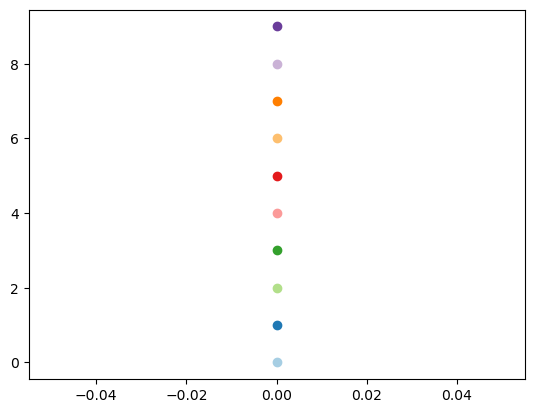

In [168]:
i = 0
for hpvGene in hpvGeneColor:
    plt.scatter(0,i,color = hpvGeneColor[hpvGene])
    i += 1

In [169]:
hpvGeneColor

{'E1': '#a6cee3',
 'E2': '#1f78b4',
 'E5_ALPHA': '#b2df8a',
 'E6': '#33a02c',
 'E7': '#fb9a99',
 'L1': '#e31a1c',
 'L2': '#fdbf6f',
 'E1^E4': '#ff7f00',
 'URR': '#cab2d6',
 'Intergenic': '#6a3d9a'}

In [170]:
commonPlotRecodeDNA

[[3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [1541854381, 9, '6560', 'type2'],
 [1541913969, 9, '2342', 'type2'],
 [1541911597, 9, '2857', 'type2'],
 [1541911597, 9, '2857', 'type2'],
 [1541854381, 9, '6560', 'type2'],
 [1541868634, 9, '2993', 'type2'],
 [1541930147, 9, '1169', 'type2'],
 [1541911597, 9, '5514', 'type2'],
 [1541930147, 9, '1169', 'type2'],
 [1541930377, 9, '1169', 'type2'],
 [1541882228, 9, '2745', 'type2'],
 [1541911597, 9, '5514', 'type2'],
 [1541868634, 9, '2993', 'type2'],
 [1541930377, 9, '1169', 'type2'],
 [1541913969, 9, '2342', 'type2'],
 [1541912467, 9, '2778', 'type2'],
 [1541912467, 9, '2778', 'type2'],
 [1541882228, 9, '2745', 'type2'],
 [1541911597, 3, '2857', 'type2'],
 [1541911597, 3, '2857', 'type2'],
 [1541911597, 3, '55

In [171]:
commonPlotRecodeDNANew = []
for each in commonPlotRecodeDNA:
    flag = False
    for gene in pave_hpvDic:
        for slot in pave_hpvDic[gene]:
            hpvSite =  each[2]
            if int(hpvSite) > int(slot[0]) and int(hpvSite) < int(slot[1]):
                hpvSite = int(hpvSite)
                
                commonPlotRecodeDNANew.append(each[0:2] + [each[-1]] + [hpvSite] + [gene])
                flag = True
    if flag == False:
        hpvSite = int(hpvSite)
        
        commonPlotRecodeDNANew.append(each[0:2] + [each[-1]] + [hpvSite] + ['Intergenic'])
                
commonPlotRecodeRNANew = []
for each in commonPlotRecodeRNA:
    flag = False
    for gene in pave_hpvDic:
        for slot in pave_hpvDic[gene]:
            for hpvSite in each[2].split(','):
                
                
                if int(hpvSite) > int(slot[0]) and int(hpvSite) < int(slot[1]):
                    hpvSite = int(hpvSite) 
                    
                    commonPlotRecodeRNANew.append(each[0:2]+ [each[-1]] + [hpvSite] + [gene])
                    flag = True
    if flag == False:
        hpvSite = int(hpvSite) 
        
        commonPlotRecodeDNANew.append(each[0:2] + [each[-1]] + [hpvSite] + ['Intergenic'])
                

In [172]:
bindingSite = [880,3358,226,409,526,2709,2582,1302,3632,5639,3689,4026,4139,3409,743,1140,720,826,605,615,634,639,696\
              ,720,826,730,3397,3390,94,7154]
bindingSiteNew = bindingSite
# for each in bindingSite:
    
    
#     newSite = int(each) - 864
    
#     if newSite < 1:
#         newSite = newSite +7905
#     bindingSiteNew.append(newSite)

In [173]:
complexInfo_df1

,SampleID,SeqID,Chro,Ins,SPCov,hpvIns,Conf,numIns,GeneFallInto,GeneWithin50k
0,2655-CB-78,Sample_2655-CB-78,11,59110346,0.306153,3077;,low;,9,FAM111B,ENST00000529891;ENST00000688864;GLYATL1B;FAM11...
1,2655-CB-78,Sample_2655-CB-78,11,59167526,0.229615,1538;,low;,9,NaN,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
2,2655-CB-78,Sample_2655-CB-78,11,59172823,0.382692,6022;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
3,2655-CB-78,Sample_2655-CB-78,11,59173849,0.306153,2540;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
4,2655-CB-78,Sample_2655-CB-78,11,59174615,0.153077,6719;,low;,9,DTX4,ENST00000529891;DTX4;FAM111B;MPEG1;RN7SL42P;FA...
...,...,...,...,...,...,...,...,...,...,...
547,SOP-021,Sample_2920-CB-83,9,123319363,0.499898,1767;,high;,7,NaN,CRB2
548,SOP-021,Sample_2920-CB-83,9,123319477,0.514959,1767;,high;,7,NaN,CRB2
549,SOP-021,Sample_2920-CB-83,9,123357240,0.999796,5585;,low;,7,CRB2,DENND1A;MIR601;CRB2
550,SOP-074,Sample_2789-CB-85,3,169496784,0.705088,1894;,high;,2,MECOM,MECOM;MECOM-AS1;RPL22P1


In [174]:
commonPlotRecodeRNA

[[3050611462, 2, '6452', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [1541912467, 2, '2778', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541911597, 2, '5514', 'type2'],
 [1541912467, 2, '2778', 'type2'],
 [1541911597, 2, '55

In [175]:
commonPlotRecodeDNANew

[[3050611462, 2, 'type1', 6452, 'L1'],
 [3050614113, 2, 'type1', 4073, 'E5_ALPHA'],
 [3050611462, 2, 'type1', 6452, 'L1'],
 [3050614113, 2, 'type1', 4073, 'E5_ALPHA'],
 [3050611462, 2, 'type1', 6452, 'L1'],
 [3050614113, 2, 'type1', 4073, 'E5_ALPHA'],
 [3050611462, 2, 'type1', 6452, 'L1'],
 [3050614113, 2, 'type1', 4073, 'E5_ALPHA'],
 [1541854381, 9, 'type2', 6560, 'L1'],
 [1541913969, 9, 'type2', 2342, 'E1'],
 [1541911597, 9, 'type2', 2857, 'E2'],
 [1541911597, 9, 'type2', 2857, 'E2'],
 [1541854381, 9, 'type2', 6560, 'L1'],
 [1541868634, 9, 'type2', 2993, 'E2'],
 [1541930147, 9, 'type2', 1169, 'E1'],
 [1541911597, 9, 'type2', 5514, 'L2'],
 [1541930147, 9, 'type2', 1169, 'E1'],
 [1541930377, 9, 'type2', 1169, 'E1'],
 [1541882228, 9, 'type2', 2745, 'E1'],
 [1541911597, 9, 'type2', 5514, 'L2'],
 [1541868634, 9, 'type2', 2993, 'E2'],
 [1541930377, 9, 'type2', 1169, 'E1'],
 [1541913969, 9, 'type2', 2342, 'E1'],
 [1541912467, 9, 'type2', 2778, 'E1'],
 [1541912467, 9, 'type2', 2778, 'E2'],
 

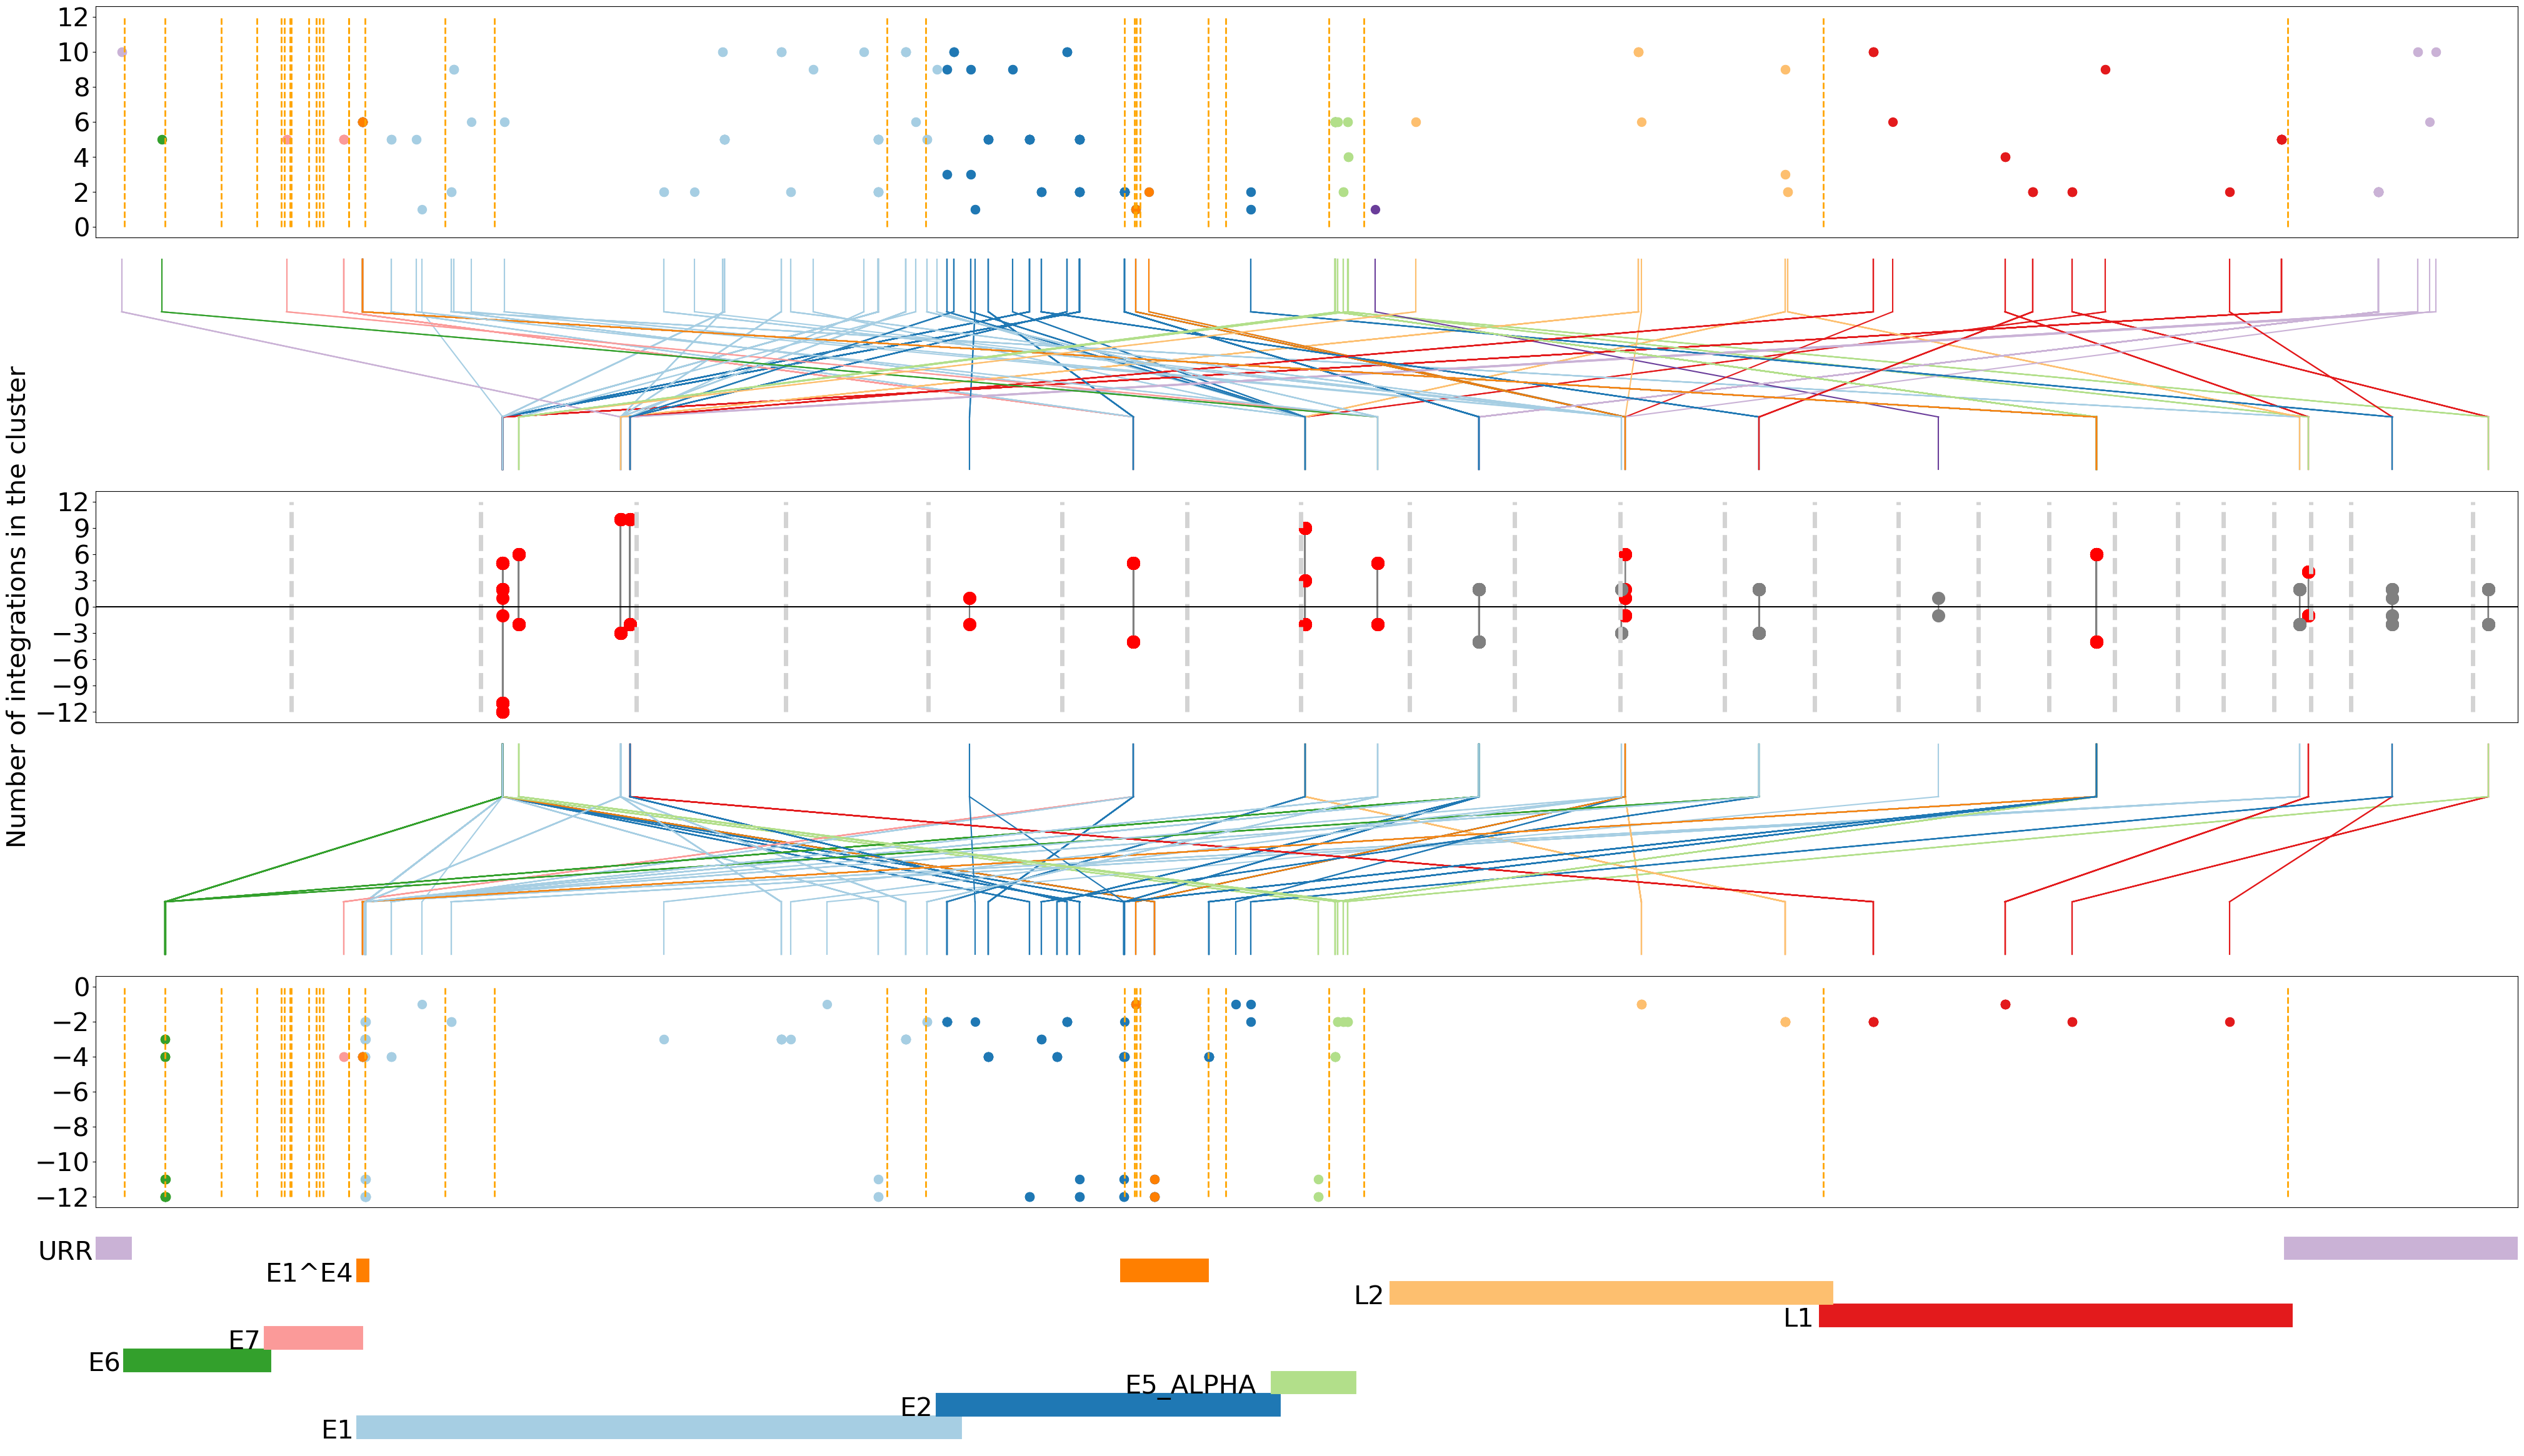

In [176]:
#figA summarize
fig = plt.figure(figsize = [50,30])
gs = fig.add_gridspec(12, 10, hspace=0.1,wspace = 0.1)
plt.rcParams['font.size'] = '30'
#hum integrations panel
ax1 = fig.add_subplot(gs[4:6, 0:10])
# add all DNA
# ylist = []
# i = 0
# for each in clusterPlotRecodeDNA:
#     x = each[0]
#     y = each[1]
#     ylist.append(y)
#     #print(x,y,size)0
#     ax1.scatter(x,y,s = 20,color = 'grey',alpha = 0.1)
#     ax1.ticklabel_format(style='plain')
#     ax1.set_xlim(0,sum(newChromsLength[0:23]))
#     for i in range(1,24):
#         ax1.vlines(x = sum(newChromsLength[0:i]),ymin = 0,ymax = max(ylist),linestyle = 'dashed',color = 'grey')
#     i += 1
# ax1.set_xticks([])
# #ax1.set_yscale('log')
# ax1.set_ylabel('Number of integrations in the cluster')
# #RNA panel        
# #ax2 = fig.add_subplot(gs[2:4, 0:10])
# ylist = []
# for each in clusterPlotRecodeRNA:
#     x = each[0]
#     y = -each[1]
#     ylist.append(y)
#     #print(x,y,size)
#     ax1.scatter(x,y,s = 20,color = 'grey',alpha = 0.1)
#     #ax1.ticklabel_format(style='plain')
#     ax1.set_xlim(0,sum(newChromsLength[0:23]))
#     for i in range(1,24):
#         ax1.vlines(x = sum(newChromsLength[0:i]),ymin = 0,ymax = -25,linestyle = 'dashed',color = 'grey')
# ax1.hlines(xmin = 0,xmax = sum(newChromsLength[0:23]),y = 0,linestyle = 'dashed',color = 'grey')


#add common integrations
#link the paired dots
i = 0
for each in commonPlotRecodeDNA:
    ax1.plot([each[0],commonPlotRecodeRNA[i][0]],[each[1],-commonPlotRecodeRNA[i][1]],'-',color = 'grey',zorder = 0)
    i += 1

ylist = []

for each in commonPlotRecodeDNA:
    x = each[0]
    y = each[1]
    ylist.append(y)
    #print(x,y,size)0
    if each[3] == 'type2':
        ax1.scatter(x,y,s = 200,color = 'red',marker = 'o', zorder = 1)
    else:
        ax1.scatter(x,y,s = 200,color = 'grey',marker = 'o')
    ax1.ticklabel_format(style='plain')
    
    
    
    
ax1.set_xticks([])
#ax1.set_yscale('log')
ax1.set_ylabel('Number of integrations in the cluster')
#RNA panel        
#ax2 = fig.add_subplot(gs[2:4, 0:10])
ylist = []
for each in commonPlotRecodeRNA:
    x = each[0]
    y = -each[1]
    ylist.append(y)
    #print(x,y,size)
    if each[3] == 'type2':
        ax1.scatter(x,y,s = 200,color = 'red',marker = 'o',zorder = 1)
    else:
        ax1.scatter(x,y,s = 200,color = 'grey',marker = 'o')
    #ax1.ticklabel_format(style='plain')
ax1.set_xlim(0,sum(newChromsLength))
for i in range(1,24):
    ax1.vlines(x = sum(newChromsLength[0:i]),ymin = -12,ymax = 12,linestyle = 'dashed',color = 'lightgrey',linewidth=5)
    #print(sum(newChromsLength[0:i]))
ax1.hlines(xmin = 0,xmax = sum(newChromsLength),y = 0,color = 'black')
ax1.set_yticks(range(-12,14,3))

#add HPV for DNA


ax3 = fig.add_subplot(gs[2:4, 0:10])
for each in commonPlotRecodeDNANew:
    
        hpvSite = int(each[3])
        #print(hpvSite)
        ax3.plot([each[0],hpvSite*sum(newChromsLength[0:24])/7906],[2,6],color = hpvGeneColor[each[4]])
        #print(each[0]+np.random.rand(1)[0]*10000)
        ax3.plot([each[0] ,each[0]],[0,2],color = hpvGeneColor[each[4]])
        ax3.plot([hpvSite*sum(newChromsLength[0:24])/7906,hpvSite*sum(newChromsLength[0:24])/7906],[6,8],color = hpvGeneColor[each[4]])
        
ax3.set_xlim(0,sum(newChromsLength[0:24]))
ax3.set_xticks([])
ax3.set_yticks([])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax2 = fig.add_subplot(gs[0:2, 0:10])
xlist = []
ylist = []
for each in commonPlotRecodeDNANew:
    
    x = int(each[3])
    y = each[1]
    xlist.append(x)
    ylist.append(y)
    #print(x,y,size)
    if each[2] == 'type2':
        ax2.scatter(x,y,s = 100,color = hpvGeneColor[each[4]],marker = 'o')
        #ax2.scatter(x,y,s = 100,hpvGeneColor[each[4]],marker = 'o')
    else:
        ax2.scatter(x,y,s = 100,color = hpvGeneColor[each[4]],marker = 'o')
    #ax2.ticklabel_format(style='plain')
    ax2.set_xlim(0,7906)
#     for gene in pave_hpvDic:
#         for slot in pave_hpvDic[gene]:
#             ax2.vlines(x = int(slot[0]),ymin = 0,ymax = 12,linestyle = 'dashed',color = 'lightgrey')
#             ax2.vlines(x = int(slot[1]),ymin = 0,ymax = 12,linestyle = 'dashed',color = 'lightgrey')
for site in bindingSite:
    ax2.vlines(x = site,ymin = 0,ymax = 12,linestyle = 'dashed',linewidth = 2,color = 'orange')
ax2.set_xticks([])
ax2.set_yticks(range(0,14,2))
offsetDic = {}
i = 1
hpvOrder = ['E1','E2','E1^E4','E5_ALPHA','L2','L1','URR','E6','E7','Intergenic']
for gene in hpvOrder:
    if i < 5:
        offsetDic[gene] = -(5-i)*1000000
    else:
        offsetDic[gene] = (i-5)*1000000
    i += 1

#add HPV integrations for RNA

#add HPV for RNA
ax6 = fig.add_subplot(gs[6:8, 0:10])
for each in commonPlotRecodeRNANew:
    hpvSite = int(each[3])
    ax6.plot([each[0],hpvSite*sum(newChromsLength[0:24])/7906],[6,2],color = hpvGeneColor[each[4]])
    #print(each[0]+np.random.rand(1)[0]*10000)
    ax6.plot([each[0] ,each[0]],[6,8],color = hpvGeneColor[each[4]])
    ax6.plot([hpvSite*sum(newChromsLength[0:24])/7906,hpvSite*sum(newChromsLength[0:24])/7906],[0,2],color = hpvGeneColor[each[4]])
        
ax6.set_xlim(0,sum(newChromsLength[0:24]))
ax6.set_xticks([])
ax6.set_yticks([])
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['bottom'].set_visible(False)
ax6.spines['left'].set_visible(False)

    
#add HPV integrations for RNA
ax5 = fig.add_subplot(gs[8:10, 0:10])
xlist = []
ylist = []
for each in commonPlotRecodeRNANew:
    hpvSite = int(each[3])
    x = int(hpvSite)
    y = -each[1]
    xlist.append(x)
    ylist.append(y)
    #print(x,y,size)
    if each[2] == 'type2':
        ax5.scatter(x,y,s = 100,color = hpvGeneColor[each[4]],marker = 'o')
    else:
        ax5.scatter(x,y,s = 100,color = hpvGeneColor[each[4]],marker = 'o')
    #ax5.ticklabel_format(style='plain')
    ax5.set_xlim(0,7906)
#     for gene in pave_hpvDic:
#         for slot in pave_hpvDic[gene]:
#             ax5.vlines(x = int(slot[0]),ymin = min(ylist),ymax = 0,linestyle = 'dashed',color = 'lightgrey')
#             ax5.vlines(x = int(slot[1]),ymin = min(ylist),ymax = 0,linestyle = 'dashed',color = 'lightgrey')
for site in bindingSite:
    ax5.vlines(x = site,ymin = min(ylist),ymax = 0,linestyle = 'dashed',linewidth = 2, color = 'orange')
    
ax5.set_xticks([])
ax5.set_yticks(range(-12,2,2))
offsetDic = {}
i = 1
hpvOrder = ['E1','E2','E1^E4','E5_ALPHA','L2','L1','URR','E6','E7','Intergenic']
for gene in hpvOrder:
    if i < 5:
        offsetDic[gene] = -(5-i)*1000000
    else:
        offsetDic[gene] = (i-5)*1000000
    i += 1
    

#virus reference panel
ax4 = fig.add_subplot(gs[10:12, 0:10])
i = 0        
for hpvGene in pave_hpvDic:
    xlist = []
    for slot in pave_hpvDic[hpvGene]:
        x = int(slot[0])
        xlist.append(x)
        step = 10
        space = 5
        y = 0 + i*step + i*space
        end = int(slot[1])
        rect = patches.Rectangle((x,y),end-x,step,linewidth=10,edgecolor=hpvGeneColor[hpvGene],\
                                 facecolor=hpvGeneColor[hpvGene])
        ax4.add_patch(rect)
    #ax4.legend(hpvGeneColor.keys())
    ax4.text(min(xlist) - 10-60*len(hpvGene),y - space/2,hpvGene)
    i += 1

ax4.set_xlim(0,7906)
ax4.set_ylim(0-10,y + space + step + 10)
ax4.set_xticks([])
ax4.set_yticks([])
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
plt.savefig('link_plot_all_sample_point_colored_2.pdf')


In [177]:
pave_hpvDic

{'E1': [['865', '2814']],
 'E2': [['2756', '3853']],
 'E5_ALPHA': [['3850', '4101']],
 'E6': [['104', '559']],
 'E7': [['562', '858']],
 'L1': [['5639', '7156']],
 'L2': [['4237', '5658']],
 'E1^E4': [['865', '880'], ['3358', '3620']],
 'URR': [['7157', '7906'], ['1', '103']]}

In [178]:
commonPlotRecodeDNA

[[3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [3050611462, 2, '6452', 'type1'],
 [3050614113, 2, '4073', 'type1'],
 [1541854381, 9, '6560', 'type2'],
 [1541913969, 9, '2342', 'type2'],
 [1541911597, 9, '2857', 'type2'],
 [1541911597, 9, '2857', 'type2'],
 [1541854381, 9, '6560', 'type2'],
 [1541868634, 9, '2993', 'type2'],
 [1541930147, 9, '1169', 'type2'],
 [1541911597, 9, '5514', 'type2'],
 [1541930147, 9, '1169', 'type2'],
 [1541930377, 9, '1169', 'type2'],
 [1541882228, 9, '2745', 'type2'],
 [1541911597, 9, '5514', 'type2'],
 [1541868634, 9, '2993', 'type2'],
 [1541930377, 9, '1169', 'type2'],
 [1541913969, 9, '2342', 'type2'],
 [1541912467, 9, '2778', 'type2'],
 [1541912467, 9, '2778', 'type2'],
 [1541882228, 9, '2745', 'type2'],
 [1541911597, 3, '2857', 'type2'],
 [1541911597, 3, '2857', 'type2'],
 [1541911597, 3, '55

In [179]:
#question2: Will HPV integrations in RNA-seq more likely to be clustered integrations than single?
onlyInRNA = {}
i = 0
for sample in resDicHPV:
    if sample in sampleConvertDic:
        if resDicHPV[sample] != []:
            for ins in resDicHPV[sample]:
                chro2 = ins.split('.')[0]
                site2 = ins.split('.')[1]
                
                common = False
                if sample in clusterCommonDic:
                    for chro in clusterCommonDic[sample]:
                        if chro == chro2:
                            for cluster in clusterCommonDic[sample][chro]:
                                for each in cluster[0]:
                                    if int(site2) == each:
                                        #print(chro,site2)
                                        common = True
                                        
                                        #print(each)
                if not common:
                    i += 1
                    if sample in onlyInRNA:
                        onlyInRNA[sample].append(chro2 + '.' + site2)
                    else:
                        onlyInRNA[sample] = [chro2 + '.' + site2]


In [180]:
#cluster the integrations
clusteredSite = {}
clusteredRNAComplexRes = {}
for sample in onlyInRNA:
    #cluster site within 500kb
    RNAList = onlyInRNA[sample]
    clusteredSite[sample] = {}
    clusteredRNAComplexRes[sample] = {}
    if RNAList != []:
        for each in RNAList:
            chro1 = each.split('.')[0]
            ins1 = int(each.split('.')[1])
            
            if chro1 in clusteredSite[sample]:
                clusteredSite[sample][chro1].append(ins1)
            else:
                clusteredSite[sample][chro1] = [ins1]
        for eachChro in clusteredSite[sample]:
            #print(clusteredSite[sample][eachChro])
            a = np.array(clusteredSite[sample][eachChro])
            #print(a)
            a = sorted(clusteredSite[sample][eachChro])
            deltaList = [0]
            for i in range(len(a)-1):
                deltaList.append(abs(a[i+1]-a[i]))
            cutList = []
            for i in range(len(deltaList)):
                if deltaList[i] > 500000:
                    cutList.append(i)
            #print(cutList)
            if cutList != []:
                clusteredRNAComplexRes[sample][eachChro] = [a[0:cutList[0]],a[cutList[-1]:]]#add the first and last slots
                for i in range(len(cutList)-1):
                    clusteredRNAComplexRes[sample][eachChro].append(a[cutList[i]:cutList[i+1]])
            else:
                clusteredRNAComplexRes[sample][eachChro] = [a]
clusteredRNAComplexResNew = {}
for sample in clusteredRNAComplexRes:
    clusteredRNAComplexResNew[sample] = {}
    for chro in clusteredRNAComplexRes[sample]:
        for cluster in clusteredRNAComplexRes[sample][chro]:
            if chro in clusteredRNAComplexResNew[sample]:
                clusteredRNAComplexResNew[sample][chro].append(list(set(cluster)))
            else:
                clusteredRNAComplexResNew[sample][chro] = [list(set(cluster))]
                                                         
    


In [181]:
for sample in clusteredRNAComplexResNew:
    for chro in clusteredRNAComplexResNew[sample]:
        for cluster in clusteredRNAComplexResNew[sample][chro]:
            if len(cluster) == 1:
                print(cluster)

[38486630]
[45007892]
[138279657]
[51202030]
[79091097]
[68456340]
[98574802]
[102815778]
[156763518]
[189170355]
[9113371]


In [182]:
#single
for sample in clusterCommonDic:
    for chro in clusterCommonDic[sample]:
        for cluster in clusterCommonDic[sample][chro]:
            if len(cluster[0]) == 1:
                print(cluster)

In [183]:
dnaResDic

{'Sample_83026': ['3.93470451.6791,7405',
  '6.76536017.7356',
  '8.63451898.1745',
  '8.120080943.6584',
  '3.93470774.6791,7405',
  '3.54562145.893',
  '11.84777199.4925',
  '16.25541381.4184',
  '12.91944711.4700,1149'],
 'Sample_83030': ['15.26038251.4414',
  '8.3990025.2128',
  '3.93470784.2480',
  '8.3866216.3233',
  '3.144105587.1347',
  '12.76962150.3916',
  '10.105009500.4357',
  '14.106781925.2249',
  '3.93470586.2480'],
 'Sample_83034': ['6.34844401.1434',
  '6.34843583.1433',
  '11.56835917.6989',
  '8.100385068.5453,1937'],
 'Sample_83044': ['9.68582624.6264',
  '10.31032491.996',
  '20.48179686.7116',
  '17.57662300.7105',
  '7.42649195.6874',
  '2.8593725.7239',
  '6.114064443.3913',
  '3.93470677.980',
  '2.71596007.3281',
  '2.123546273.2557',
  '11.5149320.5060',
  '3.178906370.3047',
  '3.93470393.980',
  '13.22775305.972',
  '2.186995465.5778'],
 'Sample_83048': ['17.82263199.2159',
  '3.78853185.2110',
  '14.65554627.1344',
  '11.21407740.1400'],
 'Sample_83060': [

In [184]:
onlyInDNA = {}
i = 0
for sample in resDicHPV:
    if sample in sampleConvertDic:
        if dnaResDic[sampleConvertDic[sample]] != []:
            for ins in dnaResDic[sampleConvertDic[sample]]:
                chro2 = ins.split('.')[0]
                site2 = ins.split('.')[1]
                common = False
                if sample in clusterCommonDic:
                    for chro in clusterCommonDic[sample]:
                        if chro == chro2:
                            for cluster in clusterCommonDic[sample][chro]:
                                for each in cluster[1]:
                                    if int(site2) == each:
                                        #print(chro,site2)
                                        common = True

                                        #print(each)
                if not common:
                    i += 1
                    if sample in onlyInDNA:
                        onlyInDNA[sample].append(chro2 + '.' + site2)
                    else:
                        onlyInDNA[sample] = [chro2 + '.' + site2]


KeyError: 'Sample_2789-CB-94'

In [ ]:
dnaResDic

In [ ]:
#cluster the integrations
clusteredSite = {}
clusteredDNAComplexRes = {}
for sample in onlyInDNA:
    #cluster site within 500kb
    DNAList = onlyInDNA[sample]
    clusteredSite[sample] = {}
    clusteredDNAComplexRes[sample] = {}
    if DNAList != []:
        for each in DNAList:
            chro1 = each.split('.')[0]
            ins1 = int(each.split('.')[1])
            
            if chro1 in clusteredSite[sample]:
                clusteredSite[sample][chro1].append(ins1)
            else:
                clusteredSite[sample][chro1] = [ins1]
        for eachChro in clusteredSite[sample]:
            #print(clusteredSite[sample][eachChro])
            a = np.array(clusteredSite[sample][eachChro])
            #print(a)
            a = sorted(clusteredSite[sample][eachChro])
            deltaList = [0]
            for i in range(len(a)-1):
                deltaList.append(abs(a[i+1]-a[i]))
            cutList = []
            for i in range(len(deltaList)):
                if deltaList[i] > 500000:
                    cutList.append(i)
            #print(cutList)
            if cutList != []:
                clusteredDNAComplexRes[sample][eachChro] = [a[0:cutList[0]],a[cutList[-1]:]]#add the first and last slots
                for i in range(len(cutList)-1):
                    clusteredDNAComplexRes[sample][eachChro].append(a[cutList[i]:cutList[i+1]])
            else:
                clusteredDNAComplexRes[sample][eachChro] = [a]
clusteredDNAComplexResNew = {}
for sample in clusteredDNAComplexRes:
    clusteredDNAComplexResNew[sample] = {}
    for chro in clusteredDNAComplexRes[sample]:
        for cluster in clusteredDNAComplexRes[sample][chro]:
            if chro in clusteredDNAComplexResNew[sample]:
                clusteredDNAComplexResNew[sample][chro].append(list(set(cluster)))
            else:
                clusteredDNAComplexResNew[sample][chro] = [list(set(cluster))]
                                                         
    


In [ ]:
i = 0
for sample in clusteredDNAComplexResNew:
    for chro in clusteredDNAComplexResNew[sample]:
        for cluster in clusteredDNAComplexResNew[sample][chro]:
            if len(cluster) == 1:
                i += 1

In [ ]:
i

In [ ]:
clusteredRNAComplexResNew

In [ ]:
#chi square test
observed = [135,49]

In [ ]:
# defining the table
data = [observed, [2114,20]]
stat, p, dof, expected = chi2_contingency(data)

In [ ]:
p

In [ ]:
expected[0]

In [ ]:
observed_simple = [2114,20]

In [ ]:
#expected = [2249*184/2309,69*2134/2308]
plt.rcParams['font.size'] = '30'
labels = ['Unique in DNA', 'Common']
x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 12))

rects1 = ax.bar(x + width/2, np.log10(observed),width, color = 'red',label='Type2',align='center')
rects2 = ax.bar(x - width/2, np.log10(observed_simple), width, color = 'grey',label='Type1',align='center')
#rects3 = ax.bar(x ,(observed_simple),width, color = 'black',alpha = 0.5,label = 'Type1')
#rects3 = ax.bar(x + width/2,np.log10(expected[1]),width,color = 'tab:orange',alpha = 0.5,label = 'Type1')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('log10 scaled Number of Integrations')
ax.set_title('Expected and observed number of integrations of type1 and type 2 ')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(prop={'size': 30})
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['bottom'].set_visible(False)
#ax.spines['left'].set_visible(False)


fig.tight_layout()
plt.savefig('type1_type2_complex_simple.pdf')

In [ ]:
# question3: Will HPV integration in DNA/RNA-seq have specific pattern when linked to HPV genome?

In [ ]:
hpvDic = {'E1': [['865', '2814']],
 'E2': [['2756', '3853']],
 'E5_ALPHA': [['3850', '4101']],
 'E6': [['104', '559']],
 'E7': [['562', '858']],
 'L1': [['5639', '7156']],
 'L2': [['4237', '5658']],
 'E1^E4': [['865', '880'], ['3358', '3620']],
 'URR': [['7157', '7906'], ['1', '103']]}
# hpvDic = {}
# for each in pave_hpvDic:
#     hpvDic[each] = []
#     for eachslot in pave_hpvDic[each]:
#         start = int(eachslot[0]) - 864
#         end = int(eachslot[1]) - 864
#         if start < 1:
#             start = start +7905
#         if end < 1:
#             end = end + 7905
#         hpvDic[each].append([start,end])

In [ ]:
dnaResDic

In [ ]:
hpvFreq = []
for sample in dnaResDic:
    for site in dnaResDic[sample]:
        
        for contig in dnaResDic[sample][site]:
            if contig[-1] == 'lowConfidence':
                hpvbreak = contig[-2]
            else:
                hpvbreak = contig[-1]
            for gene in hpvDic:
                fellIn = False
                for each in hpvDic[gene]:
                    start = each[0]
                    end = each[1]
                    if int(start) <= int(hpvbreak) and int(end) > int(hpvbreak):
                        fellIn = True
                if fellIn == True:
                    hpvFreq.append(gene)

countDic = dict(Counter(hpvFreq))


In [ ]:
totSite = 0
for each in countDic:
    totSite += countDic[each]
hpvLenDic = {}
totLen = 0
for site in hpvDic:
    hpvLen = 0
    for each in hpvDic[site]:
        hpvLen += int(each[1])-int(each[0])
    hpvLenDic[site] = hpvLen
    totLen += hpvLen
expectHPV = {}
for each in hpvLenDic:
    prob = hpvLenDic[each]/totLen
    expectCount = round(totSite*prob)
    expectHPV[each] = expectCount

In [ ]:
countDfHPV = pd.DataFrame.from_dict(countDic,orient='index')
expectHPVDf = pd.DataFrame.from_dict(expectHPV,orient = 'index')
countDfHPV = pd.DataFrame.merge(countDfHPV,expectHPVDf,left_index = True,right_index=True)
countDfHPV.columns = ['observed','expected']

In [ ]:
countDfHPV

In [ ]:
countDfHPV.index

In [ ]:
plt.rcParams['font.size'] = '10'
labels = list(countDfHPV.index)
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, countDfHPV['observed'], width, label='Observed',color = '#46499c')
rects2 = ax.bar(x + width/2, countDfHPV['expected'], width, label='Expected',color = '#f7e2db')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Integrations')
ax.set_title('Expected and observed number of integrations fall into HPV genes')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.savefig('DNA_HPV_freq.pdf')
plt.show()

In [ ]:
#chi square test
data = [countDfHPV['observed'], countDfHPV['expected']]
stat, p, dof, expected = chi2_contingency(data)

In [ ]:
p

In [ ]:
#in RNA seq

In [ ]:
resDicHPV

In [ ]:
hpvFreq = []
for sample in resDicHPV:
    for site in resDicHPV[sample]:
        hpvbreaks = site.split('.')[2].split(',')
        for hpvbreak in hpvbreaks:
            for gene in hpvDic:
                fellIn = False
                for each in hpvDic[gene]:
                    start = each[0]
                    end = each[1]
                    if int(start) <= int(hpvbreak) and int(end) > int(hpvbreak):
                        fellIn = True
                if fellIn == True:
                    hpvFreq.append(gene)

countDic = dict(Counter(hpvFreq))
totSite = 0
for each in countDic:
    totSite += countDic[each]
hpvLenDic = {}
totLen = 0
for site in hpvDic:
    hpvLen = 0
    for each in hpvDic[site]:
        hpvLen += int(each[1])-int(each[0])
    hpvLenDic[site] = hpvLen
    totLen += hpvLen
expectHPV = {}
for each in hpvLenDic:
    prob = hpvLenDic[each]/totLen
    expectCount = round(totSite*prob)
    expectHPV[each] = expectCount
countDfHPV2 = pd.DataFrame.from_dict(countDic,orient='index')
expectHPVDf = pd.DataFrame.from_dict(expectHPV,orient = 'index')
countDfHPV2 = pd.DataFrame.merge(countDfHPV,countDfHPV2,left_index = True,right_index=True)
countDfHPV2 = pd.DataFrame.merge(countDfHPV2,expectHPVDf,left_index = True,right_index=True)
countDfHPV2.columns = ['observed','expected','observed_RNA','expected_RNA']

In [ ]:
countDfHPV2

In [ ]:
plt.rcParams['font.size'] = '10'
labels = list(countDfHPV2.index)
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, countDfHPV2['observed_RNA'], width, label='Observed',color = '#46499c')
rects2 = ax.bar(x + width/2, countDfHPV2['expected_RNA'], width, label='Expected',color = '#f7e2db')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Integrations')
ax.set_title('Expected and observed number of integrations fall into HPV genes')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.savefig('RNA_HPV_freq.pdf')
plt.show()

In [ ]:
#chi square test
data = [countDfHPV2['observed_RNA'], countDfHPV2['expected_RNA']]
stat, p, dof, expected = chi2_contingency(data)

In [ ]:
p

In [ ]:
##question 4: Will common HPV integration in DNA/RNA-seq have specific pattern when linked to HPV genome?

In [ ]:
DNABreak = []
for gene in CommonSiteDNAUniq:
    if gene != 'intergenic':
        dnaList = []
        for each in CommonSiteDNAUniq[gene]:
            dnaList.append(each.split(':')[1] + ':' + each.split(':')[2])
        #print(gene,dnaList)
        for each in set(dnaList):
            hpvSites = each.split(':')[0].split('.')[2].split(',')
            for hpvSite in hpvSites:
                for gene in hpvDic:
                    fellIn = False
                    for each in hpvDic[gene]:
                        start = each[0]
                        end = each[1]
                        if int(start) <= int(hpvSite) and int(end) > int(hpvSite):
                            fellIn = True
                    if fellIn == True:
                        DNABreak.append(gene)

                
                
countDic = dict(Counter(DNABreak))
totSite = 0
for each in countDic:
    totSite += countDic[each]
hpvLenDic = {}
totLen = 0
for site in hpvDic:
    hpvLen = 0
    for each in hpvDic[site]:
        hpvLen += int(each[1])-int(each[0])
    hpvLenDic[site] = hpvLen
    totLen += hpvLen
expectHPV = {}
for each in hpvLenDic:
    prob = hpvLenDic[each]/totLen
    expectCount = round(totSite*prob)
    expectHPV[each] = expectCount
countDfHPV = pd.DataFrame.from_dict(countDic,orient='index')
expectHPVDf = pd.DataFrame.from_dict(expectHPV,orient = 'index')
countDfHPV = pd.DataFrame.merge(expectHPVDf,countDfHPV,left_index = True,right_index=True)
countDfHPV.columns = ['expected','observed']

In [ ]:
plt.rcParams['font.size'] = '10'
labels = list(countDfHPV.index)
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, countDfHPV['observed'], width, label='Observed',color = '#46499c')
rects2 = ax.bar(x + width/2, countDfHPV['expected'], width, label='Expected',color = '#f7e2db')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Integrations')
ax.set_title('Expected and observed number of integrations fall into HPV genes')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.savefig('common_DNA_HPV_freq.pdf')
plt.show()

In [ ]:
#chi square test
data = [countDfHPV['observed'], countDfHPV['expected']]
stat, p, dof, expected = chi2_contingency(data)

In [ ]:
p

In [ ]:
#in RNA-seq

In [ ]:
RNABreak = []
for gene in CommonSiteDNAUniq:
    if gene != 'intergenic':
        rnaList = []
        for each in CommonSiteDNAUniq[gene]:
            rnaList.append(each.split(':')[0] + ':' + each.split(':')[2])
        #print(gene,dnaList)
        for each in set(rnaList):
            hpvSite = each.split(':')[0].split('.')[2]
            for gene in hpvDic:
                fellIn = False
                for each in hpvDic[gene]:
                    start = each[0]
                    end = each[1]
                    if int(start) <= int(hpvSite) and int(end) > int(hpvSite):
                        fellIn = True
                if fellIn == True:
                    RNABreak.append(gene)

                
                
countDic = dict(Counter(RNABreak))
totSite = 0
for each in countDic:
    totSite += countDic[each]
hpvLenDic = {}
totLen = 0
for site in hpvDic:
    hpvLen = 0
    for each in hpvDic[site]:
        hpvLen += int(each[1])-int(each[0])
    hpvLenDic[site] = hpvLen
    totLen += hpvLen
expectHPV = {}
for each in hpvLenDic:
    prob = hpvLenDic[each]/totLen
    expectCount = round(totSite*prob)
    expectHPV[each] = expectCount
countDfHPV = pd.DataFrame.from_dict(countDic,orient='index')
expectHPVDf = pd.DataFrame.from_dict(expectHPV,orient = 'index')
countDfHPV = pd.DataFrame.merge(expectHPVDf,countDfHPV,left_index = True,right_index=True)
countDfHPV.columns = ['expected','observed']

In [ ]:
countDfHPV

In [ ]:
plt.rcParams['font.size'] = '10'
labels = list(countDfHPV.index)
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, countDfHPV['observed'], width, label='Observed',color = '#46499c')
rects2 = ax.bar(x + width/2, countDfHPV['expected'], width, label='Expected',color = '#f7e2db')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Integrations')
ax.set_title('Expected and observed number of integrations fall into HPV genes')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.savefig('common_RNA_HPV_freq.pdf')
plt.show()

In [ ]:
#chi square test
data = [countDfHPV['observed'], countDfHPV['expected']]
stat, p, dof, expected = chi2_contingency(data)

In [ ]:
p

In [ ]:
#are those HPV breakpoints overlap with binding site

In [ ]:
bindingSite = [880,3358,226,409,526,2709,2582,1302,3632,5639,3689,4026,4139,3409,743,1140,720,826,605,615,634,639,696\
              ,720,826,730,3397,3390,94,7154]

In [ ]:
bindingSiteNew = []
for each in bindingSite:
    
    
    newSite = int(each) - 864
    
    if newSite < 1:
        newSite = newSite +7905
    bindingSiteNew.append(newSite)

In [ ]:
bindingSiteNew

In [ ]:
allBreak = 0
count = 0
sampleNum = 0
for sample in resDicHPV:
    if resDicHPV[sample] != []:
        sampleNum += 1
        for site in resDicHPV[sample]:

            hpvbreaks = site.split('.')[2].split(',')
            for hpvbreak in hpvbreaks:
                #print(hpvbreak)
                allBreak += 1
                for each in bindingSiteNew:
                    if int(hpvbreak) > each - 3 and int(hpvbreak) < each + 3:
                        #print(hpvbreak)
                        count += 1
                

In [ ]:
allBreak

In [ ]:
count

In [ ]:
sampleNum

In [ ]:
len(resDicHPV)

In [ ]:
breaks = 0
for each in CommonSiteDNAUniq:
    for site in CommonSiteDNAUniq[each]:
        for each in site.split(':')[1].split('.')[2].split(','):
            breaks += 1

In [ ]:
breaks

In [ ]:
count = 0
for gene in CommonSiteDNAUniq:
    if gene != 'intergenic':
        rnaList = []
        for each in CommonSiteDNAUniq[gene]:
            rnaList.append(each.split(':')[0] + ':' + each.split(':')[2])
        #print(gene,dnaList)
        for each in set(rnaList):
            hpvSite = each.split(':')[0].split('.')[2]
            for hpvSite2 in bindingSiteNew:
                if int(hpvSite) > hpvSite2 - 3 and int(hpvSite) < hpvSite2 + 3:
                    count += 1

In [ ]:
count

In [ ]:
count = 0
for gene in CommonSiteDNAUniq:
    if gene != 'intergenic':
        rnaList = []
        for each in CommonSiteDNAUniq[gene]:
            rnaList.append(each.split(':')[1] + ':' + each.split(':')[2])
        #print(gene,dnaList)
        for each in set(rnaList):
            hpvSites = each.split(':')[0].split('.')[2].split(',')
            for hpvSite in hpvSites:
                for hpvSite2 in bindingSiteNew:
                    if int(hpvSite) > hpvSite2 - 3 and int(hpvSite) < hpvSite2 + 3:
                        count += 1

In [ ]:
count

In [ ]:
hpvDic

In [ ]:
pave_hpvDic

In [ ]:
#Question 4: how many the HPV integrations (DNA) fall into repeative regions

In [ ]:
!head /home/wenjingu/remillsscr/HPV_fusion/ref_hg19/GRCh37.repeatMasker.bed

In [ ]:
!awk '{if($4~/Alu/){print $0}}' /home/wenjingu/remillsscr/HPV_fusion/ref_hg19/GRCh37.repeatMasker.bed > /home/wenjingu/remillsscr/HPV_fusion/ref_hg19/GRCh37.alu.bed


In [ ]:
!head /home/wenjingu/remillsscr/HPV_fusion/ref_hg19/GRCh37.alu.bed

In [ ]:
count = 0
sampleCount = 0
for sample in dnaResDic:
    if dnaResDic[sample] != []:
        sampleCount += 1
        count += len(dnaResDic[sample])

In [ ]:
len(dnaResDic)

In [ ]:
count

In [ ]:
sampleCount

In [ ]:
insInAluList = '/home/wenjingu/remillsscr/HPV_fusion/targeted_exom/our_pip/newVersion/analysis/insInAlu.txt'

insInAlu = []
with open(insInAluList) as inputFile:
    rows = inputFile.read().split('\n')
    for row in rows:
        if row != '':
            insInAlu.append(row.split('\t'))

In [ ]:
countDic = {}
count = 0
for each in insInAlu:
    count += 1
    if each[2] in countDic:
        countDic[each[2]].append([each[0],each[1]])
    else:
         countDic[each[2]] = [[each[0],each[1]]]

In [ ]:
count

In [ ]:
values = []
for each in countDic:
    values.append(len(countDic[each]))

In [ ]:
plt.figure(figsize = (20,5))
plt.bar(countDic.keys(),values)
plt.xticks(rotation = 90)
plt.xlabel('types of Alu')
plt.ylabel('count')

In [ ]:
insInAlu

In [ ]:
aluList

In [ ]:
allInsDf